In [2]:
from google.colab import drive
drive.mount("/content/drive")

MessageError: Error: credential propagation was unsuccessful

In [3]:
from google.colab import files
uploaded = files.upload()

Saving consolidated_database_v8.0.zip to consolidated_database_v8.0.zip


In [4]:
from pathlib import Path
import zipfile

ZIP_PATH = Path("/content/consolidated_database_v8.0.zip")
EXTRACT_DIR = Path("/content/iceberg_data")

EXTRACT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("Files inside the ZIP:\n")
    for name in z.namelist():
        print(name)
    z.extractall(EXTRACT_DIR)

Files inside the ZIP:

updated7_consol/
updated7_consol/a01.csv
updated7_consol/a02.csv
updated7_consol/a03.csv
updated7_consol/a04.csv
updated7_consol/a05.csv
updated7_consol/a06.csv
updated7_consol/a07.csv
updated7_consol/a08.csv
updated7_consol/a09.csv
updated7_consol/a10.csv
updated7_consol/a11.csv
updated7_consol/a12.csv
updated7_consol/a13.csv
updated7_consol/a14.csv
updated7_consol/a15.csv
updated7_consol/a16.csv
updated7_consol/a17.csv
updated7_consol/a19.csv
updated7_consol/a20a.csv
updated7_consol/a20b.csv
updated7_consol/a20.csv
updated7_consol/a21a.csv
updated7_consol/a21.csv
updated7_consol/a22a.csv
updated7_consol/a22b.csv
updated7_consol/a22c.csv
updated7_consol/a22.csv
updated7_consol/a23a.csv
updated7_consol/a23b.csv
updated7_consol/a23.csv
updated7_consol/a24a.csv
updated7_consol/a24b.csv
updated7_consol/a24c.csv
updated7_consol/a24.csv
updated7_consol/a24d.csv
updated7_consol/a25.csv
updated7_consol/a26.csv
updated7_consol/a27a.csv
updated7_consol/a27.csv
updated7_co

In [5]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/content/iceberg_data/updated7_consol")

# 1. Show the dataset's own documentation
readme = DATA_DIR / "README_consolidated.TXT"
print(readme.read_text(errors="replace")[:5000])

# 2. Inspect two known iceberg tracks
for filename in ["a68a.csv", "a23a.csv"]:
    path = DATA_DIR / filename
    print("\n" + "=" * 70)
    print("FILE:", filename)

    df = pd.read_csv(path)
    print("Columns:", df.columns.tolist())
    print("Shape:", df.shape)
    display(df.head())

---------------------------------------------------------
-   BYU MERS Consolidated Antarctic Iceberg Database    -
-		Jeff Budge, BYU Nov 2016                -
- w/revisions by D.G. Long, BYU Nov 2017, Jun 2019, Aug 2019
---------------------------------------------------------

This readme is intended to explain the contents the database.
Details about how the database is created are contained in
J.S. Budge and D.G. Long, "A Comprehensive Database for Antarctic
Iceberg Tracking Using Scatterometer Data," IEEE Journal of
Selected Topics in Applied Earth Observations, accepted and
to appear, 2017. Related papers: K.M. Stuart and D.G. Long,
"Tracking large tabular icebergs using the SeaWinds Ku-band
microwave scatterometer", Deep-Sea Research Part II, 
doi:10.1016/j.dsr2.2010.11.004, Vol. 58, pp. 1285-1300, 2011.
D.G. Long, Jarom Ballantyne, and C. Bertoia, "Is the Number of
Icebergs Really Increasing?" EOS, Transactions of the American
Geophysical Union, Vol. 83, No. 42, pp. 469 & 474,

,ascat_1,ascat_2,ascat_3,date,nic_1,nic_2,nic_3,size_1,size_2
0,0.0,0.0,0,2017244,-67.9333,-60.8500,1,82,25
1,0.0,0.0,0,2017245,-67.9404,-60.8415,0,0,0
2,0.0,0.0,0,2017246,-67.9472,-60.8326,0,0,0
3,0.0,0.0,0,2017247,-67.9535,-60.8234,0,0,0
4,0.0,0.0,0,2017248,-67.9588,-60.8138,0,0,0



FILE: a23a.csv
Columns: ['ascat_1', 'ascat_2', 'ascat_3', 'date', 'ers_1', 'ers_2', 'ers_3', 'nic_1', 'nic_2', 'nic_3', 'nscat_1', 'nscat_2', 'nscat_3', 'oscat_1', 'oscat_2', 'oscat_3', 'qscat_1', 'qscat_2', 'qscat_3', 'seawinds_1', 'seawinds_2', 'seawinds_3', 'size_1', 'size_2']
Shape: (11953, 24)


,ascat_1,ascat_2,ascat_3,date,ers_1,ers_2,ers_3,nic_1,nic_2,nic_3,...,oscat_2,oscat_3,qscat_1,qscat_2,qscat_3,seawinds_1,seawinds_2,seawinds_3,size_1,size_2
0,0.0,0.0,0,1991314,0.0,0.0,0,-76.2,-41.5,1,...,0.0,0,0.0,0.0,0,0.0,0.0,0,56,39
1,0.0,0.0,0,1991315,0.0,0.0,0,-76.2,-41.5,0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0
2,0.0,0.0,0,1991316,0.0,0.0,0,-76.2,-41.5,0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0
3,0.0,0.0,0,1991317,0.0,0.0,0,-76.2,-41.5,0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0
4,0.0,0.0,0,1991318,0.0,0.0,0,-76.2,-41.5,0,...,0.0,0,0.0,0.0,0,0.0,0.0,0,0,0


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("/content/iceberg_data/updated7_consol")
SOURCE_PRIORITY = ["nic", "ascat", "oscat", "qscat", "seawinds", "ers", "nscat"]

all_tracks = []

for csv_path in DATA_DIR.glob("*.csv"):
    if csv_path.name.startswith("#"):
        continue

    raw = pd.read_csv(csv_path)

    # Important: use raw.index so every output column has one value per input row
    clean = pd.DataFrame(index=raw.index)
    clean["iceberg_id"] = csv_path.stem.upper()
    clean["date_code"] = raw["date"]

    clean["date"] = pd.to_datetime(
        clean["date_code"].astype(str),
        format="%Y%j",
        errors="coerce"
    )

    clean["latitude"] = np.nan
    clean["longitude"] = np.nan
    clean["position_source"] = None

    for source in SOURCE_PRIORITY:
        lat_col = f"{source}_1"
        lon_col = f"{source}_2"

        if lat_col not in raw.columns or lon_col not in raw.columns:
            continue

        lat = pd.to_numeric(raw[lat_col], errors="coerce")
        lon = pd.to_numeric(raw[lon_col], errors="coerce")

        valid = (
            clean["latitude"].isna()
            & lat.between(-90, -45)
            & lon.between(-180, 180)
            & (lat != 0)
            & (lon != 0)
        )

        clean.loc[valid, "latitude"] = lat[valid]
        clean.loc[valid, "longitude"] = lon[valid]
        clean.loc[valid, "position_source"] = source

    clean["length_nm"] = (
        pd.to_numeric(raw["size_1"], errors="coerce")
        if "size_1" in raw.columns else np.nan
    )
    clean["width_nm"] = (
        pd.to_numeric(raw["size_2"], errors="coerce")
        if "size_2" in raw.columns else np.nan
    )

    clean.loc[clean["length_nm"] <= 0, "length_nm"] = np.nan
    clean.loc[clean["width_nm"] <= 0, "width_nm"] = np.nan

    all_tracks.append(clean)

tracks = pd.concat(all_tracks, ignore_index=True)

tracks = (
    tracks
    .dropna(subset=["date", "latitude", "longitude"])
    .drop_duplicates(subset=["iceberg_id", "date"], keep="first")
    .sort_values(["iceberg_id", "date"])
    .reset_index(drop=True)
)

print("Clean trajectory rows:", len(tracks))
print("Icebergs:", tracks["iceberg_id"].nunique())
print("Date range:", tracks["date"].min().date(), "to", tracks["date"].max().date())
print("\nPosition sources used:")
print(tracks["position_source"].value_counts())

display(tracks.head(10))

Clean trajectory rows: 515500
Icebergs: 640
Date range: 1976-02-01 to 2026-04-30

Position sources used:
position_source
nic         243691
qscat       152483
ascat        82871
ers          33902
seawinds      2323
nscat          230
Name: count, dtype: int64


,iceberg_id,date_code,date,latitude,longitude,position_source,length_nm,width_nm
0,A01,1978295,1978-10-22,-56.0000,-34.2000,nic,45.0,25.0
1,A01,1978296,1978-10-23,-55.8415,-33.7816,nic,NaN,NaN
2,A01,1978297,1978-10-24,-55.6860,-33.3884,nic,NaN,NaN
3,A01,1978298,1978-10-25,-55.5348,-33.0347,nic,NaN,NaN
4,A01,1978299,1978-10-26,-55.3893,-32.7347,nic,NaN,NaN
5,A01,1978300,1978-10-27,-55.2508,-32.5027,nic,NaN,NaN
6,A01,1978301,1978-10-28,-55.1205,-32.3531,nic,NaN,NaN
7,A01,1978302,1978-10-29,-55.0000,-32.3000,nic,45.0,25.0
8,A01,1978316,1978-11-12,-53.7000,-35.0000,nic,45.0,20.0
9,A01,1978317,1978-11-13,-53.7000,-35.0000,nic,NaN,NaN


In [8]:
!pip -q install pyproj


  iceberg_id       date  latitude  longitude           x_m           y_m
0        A01 1978-10-22  -56.0000   -34.2000 -2.137135e+06  3.144699e+06
1        A01 1978-10-23  -55.8415   -33.7816 -2.124555e+06  3.175829e+06
2        A01 1978-10-24  -55.6860   -33.3884 -2.112857e+06  3.205728e+06
3        A01 1978-10-25  -55.5348   -33.0347 -2.102808e+06  3.233752e+06
4        A01 1978-10-26  -55.3893   -32.7347 -2.095191e+06  3.259252e+06


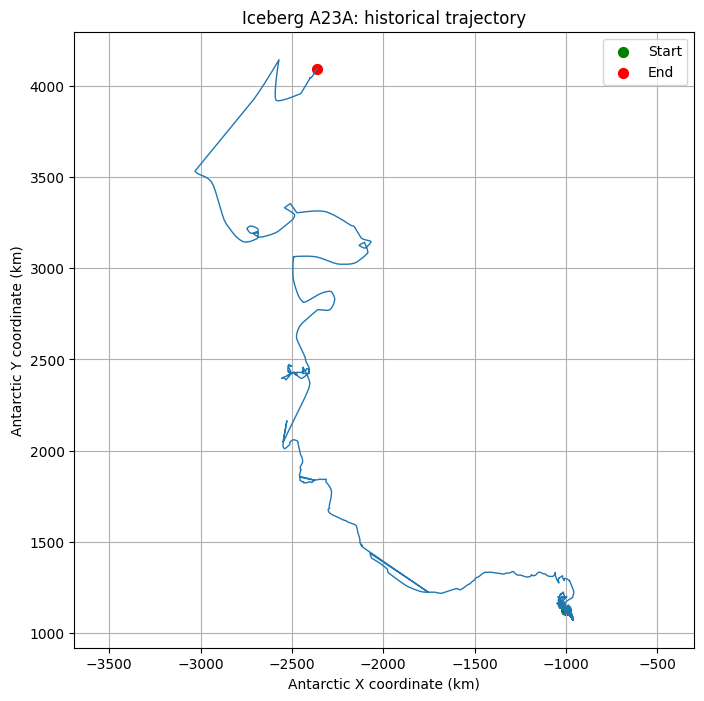

A23A records: 11864
From: 1991-11-10
To: 2026-03-31


In [9]:
from pyproj import Transformer
import matplotlib.pyplot as plt

# Geographic coordinates → Antarctic x/y coordinates in metres
to_antarctic = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3031",
    always_xy=True
)

tracks["x_m"], tracks["y_m"] = to_antarctic.transform(
    tracks["longitude"].to_numpy(),
    tracks["latitude"].to_numpy()
)

print(tracks[[
    "iceberg_id", "date", "latitude", "longitude", "x_m", "y_m"
]].head())

# Visualise one known long trajectory
example_id = "A23A"
example = tracks[tracks["iceberg_id"] == example_id].sort_values("date")

plt.figure(figsize=(8, 8))
plt.plot(example["x_m"] / 1000, example["y_m"] / 1000, linewidth=1)
plt.scatter(
    example["x_m"].iloc[0] / 1000,
    example["y_m"].iloc[0] / 1000,
    color="green",
    s=50,
    label="Start"
)
plt.scatter(
    example["x_m"].iloc[-1] / 1000,
    example["y_m"].iloc[-1] / 1000,
    color="red",
    s=50,
    label="End"
)

plt.title(f"Iceberg {example_id}: historical trajectory")
plt.xlabel("Antarctic X coordinate (km)")
plt.ylabel("Antarctic Y coordinate (km)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

print(f"{example_id} records:", len(example))
print("From:", example["date"].min().date())
print("To:", example["date"].max().date())

In [10]:
import numpy as np
from pyproj import Transformer

# Work on a separate table for ML features
ml = tracks.copy().sort_values(["iceberg_id", "date"]).reset_index(drop=True)

grouped = ml.groupby("iceberg_id", group_keys=False)

# Previous position: used to calculate current velocity
ml["prev_x_m"] = grouped["x_m"].shift(1)
ml["prev_y_m"] = grouped["y_m"].shift(1)
ml["prev_date"] = grouped["date"].shift(1)

# Next position: the target we want to predict
ml["next_x_m"] = grouped["x_m"].shift(-1)
ml["next_y_m"] = grouped["y_m"].shift(-1)
ml["next_date"] = grouped["date"].shift(-1)

# Time gaps between observations
ml["previous_gap_days"] = (ml["date"] - ml["prev_date"]).dt.days
ml["next_gap_days"] = (ml["next_date"] - ml["date"]).dt.days

# Velocity in metres per day, based on the last daily movement
ml["vx_m_per_day"] = (
    (ml["x_m"] - ml["prev_x_m"]) / ml["previous_gap_days"]
)
ml["vy_m_per_day"] = (
    (ml["y_m"] - ml["prev_y_m"]) / ml["previous_gap_days"]
)

# Keep only true consecutive daily observations:
# yesterday → today → tomorrow
ml_daily = ml[
    (ml["previous_gap_days"] == 1) &
    (ml["next_gap_days"] == 1)
].copy()

# Predict tomorrow using today's velocity
ml_daily["baseline_pred_x_m"] = ml_daily["x_m"] + ml_daily["vx_m_per_day"]
ml_daily["baseline_pred_y_m"] = ml_daily["y_m"] + ml_daily["vy_m_per_day"]

print("One-day training examples:", len(ml_daily))
print("Icebergs represented:", ml_daily["iceberg_id"].nunique())
print("Date range:", ml_daily["date"].min().date(), "to", ml_daily["date"].max().date())

display(ml_daily[[
    "iceberg_id", "date",
    "x_m", "y_m",
    "vx_m_per_day", "vy_m_per_day",
    "next_x_m", "next_y_m"
]].head())

One-day training examples: 508613
Icebergs represented: 598
Date range: 1976-12-27 to 2026-04-29


,iceberg_id,date,x_m,y_m,vx_m_per_day,vy_m_per_day,next_x_m,next_y_m
1,A01,1978-10-23,-2.124555e+06,3.175829e+06,12579.928787,31129.598514,-2.112857e+06,3.205728e+06
2,A01,1978-10-24,-2.112857e+06,3.205728e+06,11698.207846,29899.454382,-2.102808e+06,3.233752e+06
3,A01,1978-10-25,-2.102808e+06,3.233752e+06,10048.974477,28023.232882,-2.095191e+06,3.259252e+06
4,A01,1978-10-26,-2.095191e+06,3.259252e+06,7617.156821,25500.486888,-2.090821e+06,3.281591e+06
5,A01,1978-10-27,-2.090821e+06,3.281591e+06,4369.914982,22338.624232,-2.090538e+06,3.300129e+06


In [11]:
# Convert projected coordinates back to latitude/longitude
to_wgs84 = Transformer.from_crs(
    "EPSG:3031",
    "EPSG:4326",
    always_xy=True
)

def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0088

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )
    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))

# Actual tomorrow position
actual_lon, actual_lat = to_wgs84.transform(
    ml_daily["next_x_m"].to_numpy(),
    ml_daily["next_y_m"].to_numpy()
)

# Baseline-predicted tomorrow position
pred_lon, pred_lat = to_wgs84.transform(
    ml_daily["baseline_pred_x_m"].to_numpy(),
    ml_daily["baseline_pred_y_m"].to_numpy()
)

ml_daily["baseline_error_km"] = haversine_km(
    actual_lat, actual_lon,
    pred_lat, pred_lon
)

print("Constant-velocity baseline")
print(f"Mean error:   {ml_daily['baseline_error_km'].mean():.2f} km")
print(f"Median error: {ml_daily['baseline_error_km'].median():.2f} km")
print(f"90th percentile error: {ml_daily['baseline_error_km'].quantile(0.90):.2f} km")

Constant-velocity baseline
Mean error:   3.73 km
Median error: 0.05 km
90th percentile error: 9.50 km


In [12]:
!pip -q install xgboost joblib

In [13]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from pyproj import Transformer
import joblib

# 1. Add time-of-year features.
# Icebergs can move differently in different Antarctic seasons.
ml_daily = ml_daily.copy()
ml_daily["day_of_year"] = ml_daily["date"].dt.dayofyear
ml_daily["day_sin"] = np.sin(2 * np.pi * ml_daily["day_of_year"] / 365.25)
ml_daily["day_cos"] = np.cos(2 * np.pi * ml_daily["day_of_year"] / 365.25)

# 2. Our prediction target:
# how many metres the iceberg moves tomorrow in X and Y directions.
ml_daily["target_dx_m"] = ml_daily["next_x_m"] - ml_daily["x_m"]
ml_daily["target_dy_m"] = ml_daily["next_y_m"] - ml_daily["y_m"]

# 3. Inputs that XGBoost is allowed to learn from.
FEATURES = [
    "x_m",
    "y_m",
    "vx_m_per_day",
    "vy_m_per_day",
    "day_sin",
    "day_cos",
    "length_nm",
    "width_nm",
]

# Fill unknown dimensions with the median known value.
for column in ["length_nm", "width_nm"]:
    ml_daily[column] = ml_daily[column].fillna(ml_daily[column].median())

# 4. Fair evaluation:
# train on the older 80% of dates, test on the most recent 20%.
cutoff_date = ml_daily["date"].quantile(0.80)

train_df = ml_daily[ml_daily["date"] < cutoff_date].copy()
test_df = ml_daily[ml_daily["date"] >= cutoff_date].copy()

X_train = train_df[FEATURES]
X_test = test_df[FEATURES]

y_train_dx = train_df["target_dx_m"]
y_train_dy = train_df["target_dy_m"]

print("Training until:", cutoff_date.date())
print("Training examples:", len(train_df))
print("Testing examples:", len(test_df))

# 5. Train one model for east/west movement
model_dx = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

# 6. Train another model for north/south movement
model_dy = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

model_dx.fit(X_train, y_train_dx)
model_dy.fit(X_train, y_train_dy)

# 7. Predict tomorrow's movement and position
test_df["xgb_pred_x_m"] = (
    test_df["x_m"] + model_dx.predict(X_test)
)
test_df["xgb_pred_y_m"] = (
    test_df["y_m"] + model_dy.predict(X_test)
)

# 8. Convert predictions back to latitude/longitude and calculate km error
to_wgs84 = Transformer.from_crs(
    "EPSG:3031",
    "EPSG:4326",
    always_xy=True
)

actual_lon, actual_lat = to_wgs84.transform(
    test_df["next_x_m"].to_numpy(),
    test_df["next_y_m"].to_numpy()
)

xgb_lon, xgb_lat = to_wgs84.transform(
    test_df["xgb_pred_x_m"].to_numpy(),
    test_df["xgb_pred_y_m"].to_numpy()
)

baseline_lon, baseline_lat = to_wgs84.transform(
    test_df["baseline_pred_x_m"].to_numpy(),
    test_df["baseline_pred_y_m"].to_numpy()
)

test_df["xgb_error_km"] = haversine_km(
    actual_lat, actual_lon,
    xgb_lat, xgb_lon
)

test_df["baseline_error_km_test"] = haversine_km(
    actual_lat, actual_lon,
    baseline_lat, baseline_lon
)

print("\n--- Fair test-set comparison ---")
print(f"Baseline mean error: {test_df['baseline_error_km_test'].mean():.2f} km")
print(f"XGBoost mean error:  {test_df['xgb_error_km'].mean():.2f} km")
print(f"Baseline median:     {test_df['baseline_error_km_test'].median():.2f} km")
print(f"XGBoost median:      {test_df['xgb_error_km'].median():.2f} km")

# Save the trained models in the current Colab session
joblib.dump(
    {
        "model_dx": model_dx,
        "model_dy": model_dy,
        "features": FEATURES,
        "cutoff_date": str(cutoff_date.date()),
    },
    "/content/iceberg_xgboost_model.joblib"
)

print("\nModel saved as: /content/iceberg_xgboost_model.joblib")

Training until: 2020-01-17
Training examples: 406877
Testing examples: 101736

--- Fair test-set comparison ---
Baseline mean error: 1.43 km
XGBoost mean error:  2.11 km
Baseline median:     0.06 km
XGBoost median:      0.50 km

Model saved as: /content/iceberg_xgboost_model.joblib


In [14]:
# XGBoost residual model:
# It learns how to correct the baseline instead of replacing it.

from xgboost import XGBRegressor

train_residual = train_df.copy()
test_residual = test_df.copy()

# Difference between actual movement and baseline movement
train_residual["residual_dx_m"] = (
    train_residual["target_dx_m"] - train_residual["vx_m_per_day"]
)
train_residual["residual_dy_m"] = (
    train_residual["target_dy_m"] - train_residual["vy_m_per_day"]
)

residual_model_dx = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.04,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

residual_model_dy = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.04,
    min_child_weight=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

residual_model_dx.fit(
    train_residual[FEATURES],
    train_residual["residual_dx_m"]
)

residual_model_dy.fit(
    train_residual[FEATURES],
    train_residual["residual_dy_m"]
)

# Baseline position + XGBoost correction
test_residual["residual_xgb_pred_x_m"] = (
    test_residual["baseline_pred_x_m"]
    + residual_model_dx.predict(test_residual[FEATURES])
)

test_residual["residual_xgb_pred_y_m"] = (
    test_residual["baseline_pred_y_m"]
    + residual_model_dy.predict(test_residual[FEATURES])
)

# Convert to latitude/longitude for kilometre error calculation
residual_lon, residual_lat = to_wgs84.transform(
    test_residual["residual_xgb_pred_x_m"].to_numpy(),
    test_residual["residual_xgb_pred_y_m"].to_numpy()
)

test_residual["residual_xgb_error_km"] = haversine_km(
    actual_lat,
    actual_lon,
    residual_lat,
    residual_lon
)

print("--- Test-set comparison ---")
print(f"Constant velocity: {test_residual['baseline_error_km_test'].mean():.2f} km")
print(f"Direct XGBoost:    {test_df['xgb_error_km'].mean():.2f} km")
print(f"Residual XGBoost:  {test_residual['residual_xgb_error_km'].mean():.2f} km")
print()
print(f"Residual XGBoost median: "
      f"{test_residual['residual_xgb_error_km'].median():.2f} km")

--- Test-set comparison ---
Constant velocity: 1.43 km
Direct XGBoost:    2.11 km
Residual XGBoost:  1.95 km

Residual XGBoost median: 0.44 km


,Model,Mean error (km)
0,Constant velocity,1.429592
1,Direct XGBoost,2.105839
2,Residual XGBoost,1.952142


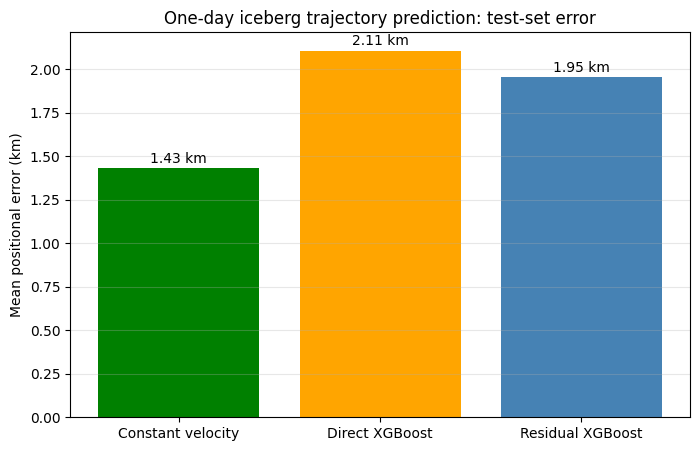

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Constant velocity",
        "Direct XGBoost",
        "Residual XGBoost"
    ],
    "Mean error (km)": [
        test_residual["baseline_error_km_test"].mean(),
        test_df["xgb_error_km"].mean(),
        test_residual["residual_xgb_error_km"].mean()
    ],
})

display(results)

plt.figure(figsize=(8, 5))
bars = plt.bar(
    results["Model"],
    results["Mean error (km)"],
    color=["green", "orange", "steelblue"]
)

plt.title("One-day iceberg trajectory prediction: test-set error")
plt.ylabel("Mean positional error (km)")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, results["Mean error (km)"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value:.2f} km",
        ha="center"
    )

plt.show()

In [16]:
!pip -q install "cdsapi>=0.7.7" xarray netcdf4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.8 MB/s eta 0:00:00


In [17]:
from getpass import getpass
from pathlib import Path

# Nothing typed here will be shown in the notebook output.
CDS_TOKEN = getpass("Paste your CDS personal access token here, then press Enter: ")

config_path = Path.home() / ".cdsapirc"

config_path.write_text(
    "url: https://cds.climate.copernicus.eu/api\n"
    f"key: {CDS_TOKEN}\n"
)

print("CDS API configuration created successfully.")

Paste your CDS personal access token here, then press Enter: ··········
CDS API configuration created successfully.


In [18]:
import cdsapi

client = cdsapi.Client()
print("Connected to the CDS API successfully.")

Connected to the CDS API successfully.


In [19]:
from pathlib import Path

WIND_SAMPLE_PATH = Path("/content/era5_wind_sample_2020_01.nc")

request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
    ],
    "year": ["2020"],
    "month": ["01"],
    "day": [f"{day:02d}" for day in range(1, 32)],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",

    # Area order: North, West, South, East
    # A small Antarctic pilot region, not the whole planet
    "area": [-55, -80, -82, 20],
}

client.retrieve(
    "reanalysis-era5-single-levels",
    request,
    str(WIND_SAMPLE_PATH)
)

print("Downloaded:", WIND_SAMPLE_PATH)
print("File size (MB):", round(WIND_SAMPLE_PATH.stat().st_size / 1024**2, 2))

2026-08-30 19:19:14,328 INFO Request ID is d67f7972-7aa7-4761-970b-a0515531dab8
INFO:ecmwf.datastores.legacy_client:Request ID is d67f7972-7aa7-4761-970b-a0515531dab8
2026-08-30 19:19:14,528 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-08-30 19:19:50,471 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-08-30 19:20:07,764 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


2af568fbde0faeceecded67a81c86e6f.nc:   0%|          | 0.00/5.00M [00:00<?, ?B/s]

Downloaded: /content/era5_wind_sample_2020_01.nc
File size (MB): 5.0


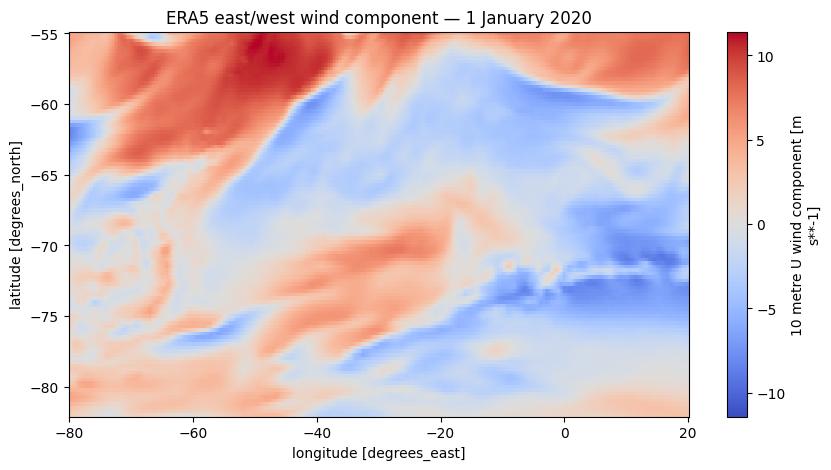

In [21]:
import matplotlib.pyplot as plt

wind_sample["u10"].isel(valid_time=0).plot(
    figsize=(10, 5),
    cmap="coolwarm"
)

plt.title("ERA5 east/west wind component — 1 January 2020")
plt.show()

In [22]:
import xarray as xr
import numpy as np

# Keep only iceberg positions covered by the downloaded ERA5 file
pilot = ml_daily[
    (ml_daily["date"] >= "2020-01-01") &
    (ml_daily["date"] <= "2020-01-31") &
    (ml_daily["latitude"].between(-82, -55)) &
    (ml_daily["longitude"].between(-80, 20))
].copy().reset_index(drop=True)

print("Iceberg positions inside the ERA5 pilot area:", len(pilot))

# Make one xarray lookup point per iceberg record
lookup_time = xr.DataArray(
    pilot["date"].to_numpy(),
    dims="sample"
)

lookup_latitude = xr.DataArray(
    pilot["latitude"].to_numpy(),
    dims="sample"
)

lookup_longitude = xr.DataArray(
    pilot["longitude"].to_numpy(),
    dims="sample"
)

# Select the closest ERA5 date + grid cell for each iceberg record
wind_at_icebergs = wind_sample[["u10", "v10"]].sel(
    valid_time=lookup_time,
    latitude=lookup_latitude,
    longitude=lookup_longitude,
    method="nearest"
)

# Attach the retrieved wind values to our iceberg table
pilot["u10_m_per_s"] = wind_at_icebergs["u10"].to_numpy()
pilot["v10_m_per_s"] = wind_at_icebergs["v10"].to_numpy()

display(pilot[[
    "iceberg_id",
    "date",
    "latitude",
    "longitude",
    "u10_m_per_s",
    "v10_m_per_s",
    "vx_m_per_day",
    "vy_m_per_day",
]].head(15))

Iceberg positions inside the ERA5 pilot area: 248


,iceberg_id,date,latitude,longitude,u10_m_per_s,v10_m_per_s,vx_m_per_day,vy_m_per_day
0,A23A,2020-01-01,-75.7833,-41.0638,5.198120,4.183640,-93.971099,-81.865083
1,A23A,2020-01-02,-75.7833,-41.0659,3.084473,3.046295,-42.897664,-37.375698
2,A23A,2020-01-03,-75.7833,-41.0667,-1.240372,2.747162,-16.341607,-14.238775
3,A23A,2020-01-04,-75.7833,-41.0658,3.354782,-0.428772,18.384322,16.018606
4,A23A,2020-01-05,-75.7833,-41.0634,2.847031,4.523102,49.026089,42.714870
5,A23A,2020-01-06,-75.7833,-41.0601,-1.853516,-1.902481,67.413793,58.729593
6,A23A,2020-01-07,-75.7833,-41.0566,-5.593552,-1.718552,71.503174,62.284719
7,A23A,2020-01-08,-75.7833,-41.0533,-0.379135,1.633667,67.420763,58.721592
8,A23A,2020-01-09,-75.7833,-41.0509,-1.123413,-2.462204,49.035406,42.704173
9,A23A,2020-01-10,-75.7833,-41.0500,-1.047806,-6.591583,18.388739,16.013535


In [23]:
a23_pilot = ml_daily[
    (ml_daily["iceberg_id"] == "A23A") &
    (ml_daily["date"] >= "2018-01-01") &
    (ml_daily["date"] <= "2020-12-31")
].copy()

print("A23A records:", len(a23_pilot))
print("Date range:", a23_pilot["date"].min().date(), "to", a23_pilot["date"].max().date())

print("\nLatitude range:")
print(a23_pilot["latitude"].min(), "to", a23_pilot["latitude"].max())

print("\nLongitude range:")
print(a23_pilot["longitude"].min(), "to", a23_pilot["longitude"].max())

display(a23_pilot[[
    "date", "latitude", "longitude",
    "vx_m_per_day", "vy_m_per_day"
]].head())

A23A records: 1083
Date range: 2018-01-01 to 2020-12-31

Latitude range:
-75.88 to -75.4363

Longitude range:
-42.0388 to -40.2


,date,latitude,longitude,vx_m_per_day,vy_m_per_day
19441,2018-01-01,-75.7833,-41.0608,279.844275,243.845612
19442,2018-01-02,-75.7833,-41.0509,202.259521,176.167952
19443,2018-01-03,-75.7833,-41.0421,179.811793,156.564394
19444,2018-01-04,-75.7833,-41.0357,130.787316,113.847666
19445,2018-01-05,-75.7833,-41.0333,49.048522,42.689108


In [24]:
from pathlib import Path

A23_WIND_PATH = Path("/content/era5_a23a_wind_2018_2020.nc")

a23_request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
    ],
    "year": ["2018", "2019", "2020"],
    "month": [f"{month:02d}" for month in range(1, 13)],
    "day": [f"{day:02d}" for day in range(1, 32)],
    "time": ["00:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",

    # Area order: North, West, South, East.
    # This box includes A23A's 2018–2020 path plus a safety margin.
    "area": [-75, -43, -77, -39],
}

client.retrieve(
    "reanalysis-era5-single-levels",
    a23_request,
    str(A23_WIND_PATH)
)

print("Download finished:", A23_WIND_PATH)
print("File size (MB):", round(A23_WIND_PATH.stat().st_size / 1024**2, 2))

2026-08-30 19:28:11,758 INFO Request ID is 1a5e44a5-f0ed-4c2d-9265-5dfd141c39f8
INFO:ecmwf.datastores.legacy_client:Request ID is 1a5e44a5-f0ed-4c2d-9265-5dfd141c39f8
2026-08-30 19:28:11,965 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-08-30 19:28:46,269 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-08-30 19:32:34,559 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


90ebf89eeb2ec675738f289581a4b1b4.nc:   0%|          | 0.00/786k [00:00<?, ?B/s]

Download finished: /content/era5_a23a_wind_2018_2020.nc
File size (MB): 0.77


In [25]:
a23_wind = xr.open_dataset("/content/era5_a23a_wind_2018_2020.nc")

print(a23_wind)

<xarray.Dataset> Size: 1MB
Dimensions:     (valid_time: 1096, latitude: 9, longitude: 17)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 9kB 2018-01-01 ... 2020-12-31
  * latitude    (latitude) float64 72B -75.0 -75.25 -75.5 ... -76.5 -76.75 -77.0
  * longitude   (longitude) float64 136B -43.0 -42.75 -42.5 ... -39.25 -39.0
    number      int64 8B ...
    expver      (valid_time) <U4 18kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 671kB ...
    v10         (valid_time, latitude, longitude) float32 671kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-08-30T19:31 GRIB to CDM+CF via cfgrib-0.9.1...


In [26]:
# Start with A23A's 1,083 daily trajectory records
a23_ml = a23_pilot.copy().reset_index(drop=True)

# Look up the closest ERA5 wind value for every A23A position/date
a23_wind_at_position = a23_wind[["u10", "v10"]].sel(
    valid_time=xr.DataArray(a23_ml["date"].to_numpy(), dims="sample"),
    latitude=xr.DataArray(a23_ml["latitude"].to_numpy(), dims="sample"),
    longitude=xr.DataArray(a23_ml["longitude"].to_numpy(), dims="sample"),
    method="nearest"
)

# Add the two environmental features to the trajectory table
a23_ml["u10_m_per_s"] = a23_wind_at_position["u10"].to_numpy()
a23_ml["v10_m_per_s"] = a23_wind_at_position["v10"].to_numpy()

# Safety check: every iceberg row should now have wind data
print("A23A rows:", len(a23_ml))
print("Missing u10 values:", a23_ml["u10_m_per_s"].isna().sum())
print("Missing v10 values:", a23_ml["v10_m_per_s"].isna().sum())

display(a23_ml[[
    "date",
    "latitude",
    "longitude",
    "u10_m_per_s",
    "v10_m_per_s",
    "vx_m_per_day",
    "vy_m_per_day",
]].head(10))

A23A rows: 1083
Missing u10 values: 0
Missing v10 values: 0


,date,latitude,longitude,u10_m_per_s,v10_m_per_s,vx_m_per_day,vy_m_per_day
0,2018-01-01,-75.7833,-41.0608,-2.400772,-0.387299,279.844275,243.845612
1,2018-01-02,-75.7833,-41.0509,-0.812820,0.117462,202.259521,176.167952
2,2018-01-03,-75.7833,-41.0421,1.333023,4.008606,179.811793,156.564394
3,2018-01-04,-75.7833,-41.0357,6.822433,4.869553,130.787316,113.847666
4,2018-01-05,-75.7833,-41.0333,2.052551,-2.045181,49.048522,42.689108
5,2018-01-06,-75.7833,-41.0333,0.932281,-1.570908,0.000000,0.000000
6,2018-01-07,-75.7833,-41.0333,-0.131088,2.884521,0.000000,0.000000
7,2018-01-08,-75.7833,-41.0333,-3.671112,-2.366669,0.000000,0.000000
8,2018-01-09,-75.7833,-41.0333,2.215942,3.145844,0.000000,0.000000
9,2018-01-10,-75.7833,-41.0333,2.266434,1.143723,0.000000,0.000000


In [27]:
from xgboost import XGBRegressor
from pyproj import Transformer
import numpy as np

# Add seasonal information
a23_ml = a23_ml.copy()
a23_ml["day_of_year"] = a23_ml["date"].dt.dayofyear
a23_ml["day_sin"] = np.sin(2 * np.pi * a23_ml["day_of_year"] / 365.25)
a23_ml["day_cos"] = np.cos(2 * np.pi * a23_ml["day_of_year"] / 365.25)

# This model learns the correction needed beyond constant velocity
a23_ml["residual_dx_m"] = (
    a23_ml["target_dx_m"] - a23_ml["vx_m_per_day"]
)
a23_ml["residual_dy_m"] = (
    a23_ml["target_dy_m"] - a23_ml["vy_m_per_day"]
)

WIND_FEATURES = [
    "x_m",
    "y_m",
    "vx_m_per_day",
    "vy_m_per_day",
    "u10_m_per_s",
    "v10_m_per_s",
    "day_sin",
    "day_cos",
]

# Fair evaluation:
# Learn from 2018–2019; predict unseen dates in 2020.
a23_train = a23_ml[a23_ml["date"] < "2020-01-01"].copy()
a23_test = a23_ml[a23_ml["date"] >= "2020-01-01"].copy()

print("Training rows:", len(a23_train))
print("Testing rows:", len(a23_test))

wind_model_dx = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.04,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

wind_model_dy = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.04,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=10,
    objective="reg:squarederror",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)

wind_model_dx.fit(
    a23_train[WIND_FEATURES],
    a23_train["residual_dx_m"]
)

wind_model_dy.fit(
    a23_train[WIND_FEATURES],
    a23_train["residual_dy_m"]
)

# Baseline prediction + wind-aware correction
a23_test["wind_xgb_pred_x_m"] = (
    a23_test["baseline_pred_x_m"]
    + wind_model_dx.predict(a23_test[WIND_FEATURES])
)

a23_test["wind_xgb_pred_y_m"] = (
    a23_test["baseline_pred_y_m"]
    + wind_model_dy.predict(a23_test[WIND_FEATURES])
)

# Convert actual and predicted points back to latitude/longitude
to_wgs84 = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)

actual_lon, actual_lat = to_wgs84.transform(
    a23_test["next_x_m"].to_numpy(),
    a23_test["next_y_m"].to_numpy()
)

baseline_lon, baseline_lat = to_wgs84.transform(
    a23_test["baseline_pred_x_m"].to_numpy(),
    a23_test["baseline_pred_y_m"].to_numpy()
)

wind_lon, wind_lat = to_wgs84.transform(
    a23_test["wind_xgb_pred_x_m"].to_numpy(),
    a23_test["wind_xgb_pred_y_m"].to_numpy()
)

a23_test["baseline_error_km"] = haversine_km(
    actual_lat, actual_lon, baseline_lat, baseline_lon
)

a23_test["wind_xgb_error_km"] = haversine_km(
    actual_lat, actual_lon, wind_lat, wind_lon
)

print("\n--- A23A: 2020 unseen test data ---")
print(f"Constant-velocity baseline: {a23_test['baseline_error_km'].mean():.3f} km")
print(f"Wind-aware XGBoost:         {a23_test['wind_xgb_error_km'].mean():.3f} km")
print(f"Baseline median:             {a23_test['baseline_error_km'].median():.3f} km")
print(f"Wind-aware median:           {a23_test['wind_xgb_error_km'].median():.3f} km")

Training rows: 717
Testing rows: 366

--- A23A: 2020 unseen test data ---
Constant-velocity baseline: 0.249 km
Wind-aware XGBoost:         2.607 km
Baseline median:             0.033 km
Wind-aware median:           1.139 km


,Model,Mean error (km),Median error (km)
0,Constant velocity,0.248508,0.033153
1,Wind-aware XGBoost,2.606692,1.138853


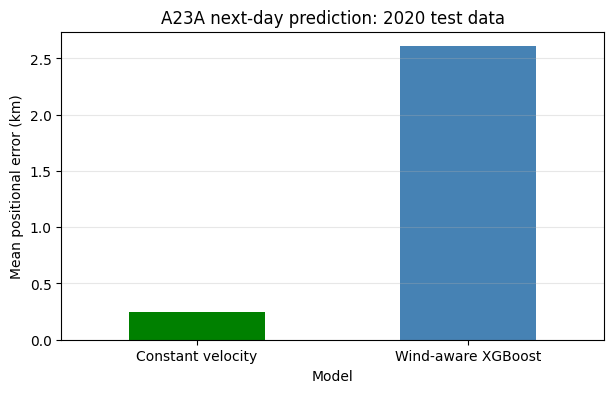

Saved: /content/a23a_2020_prediction_results.csv


In [28]:
import pandas as pd
import matplotlib.pyplot as plt

a23_results = pd.DataFrame({
    "Model": ["Constant velocity", "Wind-aware XGBoost"],
    "Mean error (km)": [
        a23_test["baseline_error_km"].mean(),
        a23_test["wind_xgb_error_km"].mean(),
    ],
    "Median error (km)": [
        a23_test["baseline_error_km"].median(),
        a23_test["wind_xgb_error_km"].median(),
    ],
})

display(a23_results)

a23_results.plot(
    x="Model",
    y="Mean error (km)",
    kind="bar",
    legend=False,
    color=["green", "steelblue"],
    figsize=(7, 4),
    title="A23A next-day prediction: 2020 test data"
)

plt.ylabel("Mean positional error (km)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

a23_test.to_csv(
    "/content/a23a_2020_prediction_results.csv",
    index=False
)

print("Saved: /content/a23a_2020_prediction_results.csv")

In [29]:
from google.colab import files
files.download("/content/a23a_2020_prediction_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
!pip -q install copernicusmarine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 114.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 9.9 MB/s eta 0:00:00


In [31]:
import copernicusmarine
copernicusmarine.login()

INFO - 2026-08-30T19:47:52Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register
INFO:copernicusmarine:Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username: archit.dbpc@gmail.com
Copernicus Marine password: ··········


INFO - 2026-08-30T19:48:31Z - Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.
INFO:copernicusmarine:Credentials file stored in /root/.copernicusmarine/.copernicusmarine-credentials.


True

In [36]:
from pathlib import Path
import copernicusmarine

CURRENT_PATH = Path("/content/a23a_ocean_currents_2018_2020.nc")

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["uo", "vo"],

    # Same small A23A study area
    minimum_longitude=-43,
    maximum_longitude=-39,
    minimum_latitude=-77,
    maximum_latitude=-75,

    # Surface ocean layer
   minimum_depth=0.49402499198913574,
maximum_depth=0.49402499198913574,

    start_datetime="2018-01-01T00:00:00",
    end_datetime="2020-12-31T00:00:00",

    output_directory="/content",
    output_filename=CURRENT_PATH.name,
)

print("Downloaded:", CURRENT_PATH)
print("File size (MB):", round(CURRENT_PATH.stat().st_size / 1024**2, 2))

INFO - 2026-08-30T19:56:53Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-08-30T19:56:53Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


ValueError: unrecognized engine 'zarr' must be one of your download engines: ['netcdf4', 'h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

In [37]:
# 1. Install the missing Zarr reader
!pip -q install --upgrade "zarr>=3" "numcodecs>=0.15"

# 2. Refresh Xarray so it detects the newly installed Zarr engine
import zarr
import xarray as xr
from xarray.backends.plugins import list_engines

list_engines.cache_clear()

print("Available Xarray engines:", list(list_engines().keys()))
print("Zarr version:", zarr.__version__)

# 3. Download A23A's near-surface ocean currents
from pathlib import Path
import copernicusmarine

CURRENT_PATH = Path("/content/a23a_ocean_currents_2018_2020.nc")

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["uo", "vo"],

    # A23A study area
    minimum_longitude=-43,
    maximum_longitude=-39,
    minimum_latitude=-77,
    maximum_latitude=-75,

    # Exact shallowest current layer in this product
    minimum_depth=0.49402499198913574,
    maximum_depth=0.49402499198913574,

    start_datetime="2018-01-01T00:00:00",
    end_datetime="2020-12-31T00:00:00",

    output_directory="/content",
    output_filename="a23a_ocean_currents_2018_2020.nc",
)

print("\nDownload finished:", CURRENT_PATH)
print("File size (MB):", round(CURRENT_PATH.stat().st_size / 1024**2, 2))

Available Xarray engines: ['netcdf4', 'h5netcdf', 'scipy', 'store']
Zarr version: 3.3.0


INFO - 2026-08-30T19:58:31Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-08-30T19:58:31Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


ValueError: unrecognized engine 'zarr' must be one of your download engines: ['netcdf4', 'h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

In [35]:
!pip -q install "zarr>=3"

In [38]:
# 1. Install the missing Zarr reader
!pip -q install --upgrade "zarr>=3" "numcodecs>=0.15"

# 2. Refresh Xarray so it detects the newly installed Zarr engine
import zarr
import xarray as xr
from xarray.backends.plugins import list_engines

list_engines.cache_clear()

print("Available Xarray engines:", list(list_engines().keys()))
print("Zarr version:", zarr.__version__)

# 3. Download A23A's near-surface ocean currents
from pathlib import Path
import copernicusmarine

CURRENT_PATH = Path("/content/a23a_ocean_currents_2018_2020.nc")

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["uo", "vo"],

    # A23A study area
    minimum_longitude=-43,
    maximum_longitude=-39,
    minimum_latitude=-77,
    maximum_latitude=-75,

    # Exact shallowest current layer in this product
    minimum_depth=0.49402499198913574,
    maximum_depth=0.49402499198913574,

    start_datetime="2018-01-01T00:00:00",
    end_datetime="2020-12-31T00:00:00",

    output_directory="/content",
    output_filename="a23a_ocean_currents_2018_2020.nc",
)

print("\nDownload finished:", CURRENT_PATH)
print("File size (MB):", round(CURRENT_PATH.stat().st_size / 1024**2, 2))

Available Xarray engines: ['netcdf4', 'h5netcdf', 'scipy', 'store']
Zarr version: 3.3.0


INFO - 2026-08-30T19:58:52Z - Selected dataset version: "202311"
INFO:copernicusmarine:Selected dataset version: "202311"
INFO - 2026-08-30T19:58:52Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


ValueError: unrecognized engine 'zarr' must be one of your download engines: ['netcdf4', 'h5netcdf', 'scipy', 'store']. To install additional dependencies, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

In [39]:
# Fix Colab's missing Zarr registration
import xarray as xr
import zarr
import xarray.backends.plugins as xr_plugins
from xarray.backends.zarr import ZarrBackendEntrypoint

xr_plugins.BACKEND_ENTRYPOINTS["zarr"] = (
    "zarr",
    ZarrBackendEntrypoint
)

xr_plugins.list_engines.cache_clear()

print("Available engines:", list(xr_plugins.list_engines().keys()))
assert "zarr" in xr_plugins.list_engines(), "Zarr registration failed"

# Download A23A's surface ocean-current data
from pathlib import Path
import copernicusmarine

CURRENT_PATH = Path("/content/a23a_ocean_currents_2018_2020.nc")

copernicusmarine.subset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["uo", "vo"],

    minimum_longitude=-43,
    maximum_longitude=-39,
    minimum_latitude=-77,
    maximum_latitude=-75,

    # Exact shallowest depth in this ocean-current dataset
    minimum_depth=0.49402499198913574,
    maximum_depth=0.49402499198913574,

    start_datetime="2018-01-01T00:00:00",
    end_datetime="2020-12-31T00:00:00",

    output_directory="/content",
    output_filename="a23a_ocean_currents_2018_2020.nc",
)

print("\nDownload finished:", CURRENT_PATH)
print("File size (MB):", round(CURRENT_PATH.stat().st_size / 1024**2, 2))

Available engines: ['netcdf4', 'h5netcdf', 'scipy', 'store']


AssertionError: Zarr registration failed

In [40]:
import numpy as np
import pandas as pd
from pyproj import Transformer

# Use the same chronological test period as before
TEST_START = pd.Timestamp("2020-01-17")

evaluation_base = tracks.copy().sort_values(
    ["iceberg_id", "date"]
).reset_index(drop=True)

grouped = evaluation_base.groupby("iceberg_id", group_keys=False)

# Yesterday's position, needed to calculate latest velocity
evaluation_base["prev_x_m"] = grouped["x_m"].shift(1)
evaluation_base["prev_y_m"] = grouped["y_m"].shift(1)
evaluation_base["prev_date"] = grouped["date"].shift(1)

evaluation_base["previous_gap_days"] = (
    evaluation_base["date"] - evaluation_base["prev_date"]
).dt.days

evaluation_base["vx_m_per_day"] = (
    (evaluation_base["x_m"] - evaluation_base["prev_x_m"])
    / evaluation_base["previous_gap_days"]
)

evaluation_base["vy_m_per_day"] = (
    (evaluation_base["y_m"] - evaluation_base["prev_y_m"])
    / evaluation_base["previous_gap_days"]
)

to_wgs84 = Transformer.from_crs("EPSG:3031", "EPSG:4326", always_xy=True)

def evaluate_baseline_horizon(days_ahead):
    data = evaluation_base.copy()

    data["future_x_m"] = data.groupby("iceberg_id")["x_m"].shift(-days_ahead)
    data["future_y_m"] = data.groupby("iceberg_id")["y_m"].shift(-days_ahead)
    data["future_date"] = data.groupby("iceberg_id")["date"].shift(-days_ahead)

    # Only use true continuous daily history and a true target exactly N days later
    valid = data[
        (data["previous_gap_days"] == 1) &
        ((data["future_date"] - data["date"]).dt.days == days_ahead) &
        (data["date"] >= TEST_START)
    ].copy()

    valid["pred_x_m"] = valid["x_m"] + valid["vx_m_per_day"] * days_ahead
    valid["pred_y_m"] = valid["y_m"] + valid["vy_m_per_day"] * days_ahead

    actual_lon, actual_lat = to_wgs84.transform(
        valid["future_x_m"].to_numpy(),
        valid["future_y_m"].to_numpy()
    )

    pred_lon, pred_lat = to_wgs84.transform(
        valid["pred_x_m"].to_numpy(),
        valid["pred_y_m"].to_numpy()
    )

    valid["error_km"] = haversine_km(
        actual_lat, actual_lon,
        pred_lat, pred_lon
    )

    return {
        "Forecast horizon": f"{days_ahead} day",
        "Test examples": len(valid),
        "Mean error (km)": valid["error_km"].mean(),
        "Median error (km)": valid["error_km"].median(),
        "90th percentile (km)": valid["error_km"].quantile(0.90),
    }

final_metrics = pd.DataFrame([
    evaluate_baseline_horizon(1),
    evaluate_baseline_horizon(3),
    evaluate_baseline_horizon(7),
])

display(final_metrics.round(3))

,Forecast horizon,Test examples,Mean error (km),Median error (km),90th percentile (km)
0,1 day,101736,1.430,0.056,2.560
1,3 day,100615,4.990,0.447,11.985
2,7 day,98936,14.823,2.367,38.883


Latest dataset observation: 2026-03-31


,iceberg_id,forecast_day,forecast_date,predicted_latitude,predicted_longitude,estimated_uncertainty_km
0,A23A,1,2026-04-01,-48.3440,-29.8273,1.4296
1,A23A,2,2026-04-02,-48.2995,-29.6399,2.8592
2,A23A,3,2026-04-03,-48.2546,-29.4529,4.2888
3,A23A,4,2026-04-04,-48.2093,-29.2664,5.7184
4,A23A,5,2026-04-05,-48.1637,-29.0802,7.1480
5,A23A,6,2026-04-06,-48.1176,-28.8946,8.5776
6,A23A,7,2026-04-07,-48.0711,-28.7094,10.0071


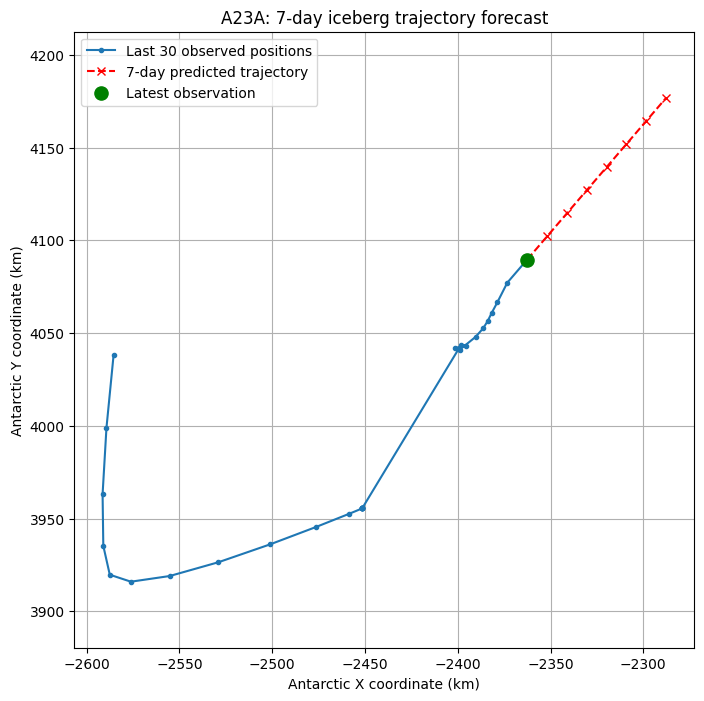

Saved: /content/a23a_7_day_forecast.csv
Saved: /content/trajectory_model_metrics.csv


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FORECAST_ICEBERG = "A23A"
FORECAST_DAYS = 7

# Find the last two available A23A positions
history = tracks[
    tracks["iceberg_id"] == FORECAST_ICEBERG
].sort_values("date").copy()

last = history.iloc[-1]
previous = history.iloc[-2]

# Latest daily movement
gap_days = (last["date"] - previous["date"]).days

vx_m_per_day = (last["x_m"] - previous["x_m"]) / gap_days
vy_m_per_day = (last["y_m"] - previous["y_m"]) / gap_days

# Predict positions for the next 7 days
steps = np.arange(1, FORECAST_DAYS + 1)

predicted_x = last["x_m"] + vx_m_per_day * steps
predicted_y = last["y_m"] + vy_m_per_day * steps

predicted_lon, predicted_lat = to_wgs84.transform(
    predicted_x,
    predicted_y
)

# Use your measured 1-day test error as a simple uncertainty estimate
one_day_error_km = float(
    final_metrics.loc[
        final_metrics["Forecast horizon"] == "1 day",
        "Mean error (km)"
    ].iloc[0]
)

forecast = pd.DataFrame({
    "iceberg_id": FORECAST_ICEBERG,
    "forecast_day": steps,
    "forecast_date": last["date"] + pd.to_timedelta(steps, unit="D"),
    "predicted_latitude": predicted_lat,
    "predicted_longitude": predicted_lon,
    "estimated_uncertainty_km": one_day_error_km * steps,
})

print("Latest dataset observation:", last["date"].date())
display(forecast.round(4))

# Plot the last 30 observations plus forecast
recent = history.tail(30)

plt.figure(figsize=(8, 8))

plt.plot(
    recent["x_m"] / 1000,
    recent["y_m"] / 1000,
    marker="o",
    markersize=3,
    label="Last 30 observed positions"
)

plt.plot(
    [last["x_m"] / 1000] + list(predicted_x / 1000),
    [last["y_m"] / 1000] + list(predicted_y / 1000),
    marker="x",
    linestyle="--",
    color="red",
    label="7-day predicted trajectory"
)

plt.scatter(
    last["x_m"] / 1000,
    last["y_m"] / 1000,
    color="green",
    s=90,
    zorder=5,
    label="Latest observation"
)

plt.title("A23A: 7-day iceberg trajectory forecast")
plt.xlabel("Antarctic X coordinate (km)")
plt.ylabel("Antarctic Y coordinate (km)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

forecast.to_csv("/content/a23a_7_day_forecast.csv", index=False)
final_metrics.to_csv("/content/trajectory_model_metrics.csv", index=False)

print("Saved: /content/a23a_7_day_forecast.csv")
print("Saved: /content/trajectory_model_metrics.csv")

In [42]:
from google.colab import files
uploaded = files.upload()

Saving cmems_mod_glo_phy_my_0.083deg_P1D-m_1788122023641.nc to cmems_mod_glo_phy_my_0.083deg_P1D-m_1788122023641.nc


In [44]:
import xarray as xr

currents = xr.open_dataset(f"/content/{CURRENT_FILE}")

print(currents)

NameError: name 'CURRENT_FILE' is not defined

In [45]:
from google.colab import files
import xarray as xr

# Select and upload the downloaded .nc file
uploaded = files.upload()

# Automatically remember its filename
CURRENT_FILE = next(iter(uploaded))

# Open it as ocean-current data
currents = xr.open_dataset(f"/content/{CURRENT_FILE}")

print("Uploaded file:", CURRENT_FILE)
print(currents)

Saving cmems_mod_glo_phy_my_0.083deg_P1D-m_1788122023641.nc to cmems_mod_glo_phy_my_0.083deg_P1D-m_1788122023641 (1).nc
Uploaded file: cmems_mod_glo_phy_my_0.083deg_P1D-m_1788122023641 (1).nc
<xarray.Dataset> Size: 11MB
Dimensions:    (time: 1096, depth: 1, latitude: 25, longitude: 48)
Coordinates:
  * time       (time) datetime64[ns] 9kB 2018-01-01 2018-01-02 ... 2020-12-31
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 100B -77.0 -76.92 -76.83 ... -75.08 -75.0
  * longitude  (longitude) float32 192B -43.0 -42.92 -42.83 ... -39.17 -39.08
Data variables:
    uo         (time, depth, latitude, longitude) float32 5MB ...
    vo         (time, depth, latitude, longitude) float32 5MB ...
Attributes:
    Conventions:       CF-1.11
    title:             daily mean fields from Global Ocean Physics Analysis a...
    institution:       MERCATOR OCEAN
    source:            MERCATOR GLORYS12V1
    history:           2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
 

In [46]:
import xarray as xr
import numpy as np

# Find the nearest ocean-current grid point for every A23A daily record
current_at_position = currents[["uo", "vo"]].sel(
    time=xr.DataArray(a23_ml["date"].to_numpy(), dims="sample"),
    latitude=xr.DataArray(a23_ml["latitude"].to_numpy(), dims="sample"),
    longitude=xr.DataArray(a23_ml["longitude"].to_numpy(), dims="sample"),
    method="nearest"
).isel(depth=0)

# Add ocean-current features to A23A's ML table
a23_ml["uo_m_per_s"] = current_at_position["uo"].to_numpy()
a23_ml["vo_m_per_s"] = current_at_position["vo"].to_numpy()

print("A23A rows:", len(a23_ml))
print("Missing uo values:", a23_ml["uo_m_per_s"].isna().sum())
print("Missing vo values:", a23_ml["vo_m_per_s"].isna().sum())

display(a23_ml[[
    "date",
    "u10_m_per_s", "v10_m_per_s",
    "uo_m_per_s", "vo_m_per_s",
    "vx_m_per_day", "vy_m_per_day",
]].head(10))

A23A rows: 1083
Missing uo values: 0
Missing vo values: 0


,date,u10_m_per_s,v10_m_per_s,uo_m_per_s,vo_m_per_s,vx_m_per_day,vy_m_per_day
0,2018-01-01,-2.400772,-0.387299,0.006714,-0.033570,279.844275,243.845612
1,2018-01-02,-0.812820,0.117462,-0.049440,0.001831,202.259521,176.167952
2,2018-01-03,1.333023,4.008606,-0.090945,0.084841,179.811793,156.564394
3,2018-01-04,6.822433,4.869553,-0.016480,0.057985,130.787316,113.847666
4,2018-01-05,2.052551,-2.045181,0.033570,0.015259,49.048522,42.689108
5,2018-01-06,0.932281,-1.570908,-0.008545,0.012818,0.000000,0.000000
6,2018-01-07,-0.131088,2.884521,0.045778,-0.034181,0.000000,0.000000
7,2018-01-08,-3.671112,-2.366669,0.000000,-0.022584,0.000000,0.000000
8,2018-01-09,2.215942,3.145844,-0.072634,0.026856,0.000000,0.000000
9,2018-01-10,2.266434,1.143723,-0.017090,0.001221,0.000000,0.000000


A23A model: train on 2018–2019; test on unseen 2020 data


,Forecast horizon,Test examples,Baseline mean error (km),Wind + current model mean error (km),Wind + current model median error (km)
0,1 day,365,0.249,1.758,1.273
1,3 day,363,1.116,5.818,3.424
2,7 day,359,3.497,13.073,6.276


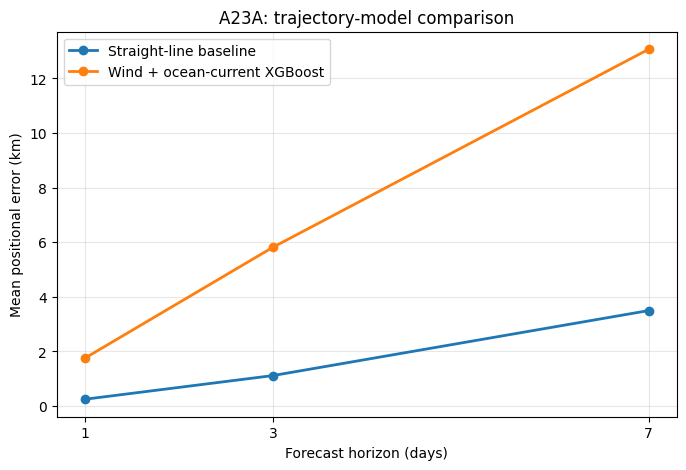

Saved model: /content/a23a_wind_current_trajectory_models.joblib


In [47]:
from xgboost import XGBRegressor
from pyproj import Transformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# ------------------------------------------------------------
# A23A data + features available at the prediction date
# ------------------------------------------------------------
multi_data = a23_ml.copy().sort_values("date").reset_index(drop=True)

multi_data["day_of_year"] = multi_data["date"].dt.dayofyear
multi_data["day_sin"] = np.sin(
    2 * np.pi * multi_data["day_of_year"] / 365.25
)
multi_data["day_cos"] = np.cos(
    2 * np.pi * multi_data["day_of_year"] / 365.25
)

# Size is only a fragmentation proxy for now.
# Proper fragmentation detection comes later from satellite imagery.
multi_data["area_proxy_nm2"] = (
    multi_data["length_nm"] * multi_data["width_nm"]
)

FEATURES_MULTI = [
    "x_m",
    "y_m",
    "vx_m_per_day",
    "vy_m_per_day",
    "u10_m_per_s",
    "v10_m_per_s",
    "uo_m_per_s",
    "vo_m_per_s",
    "day_sin",
    "day_cos",
    "length_nm",
    "width_nm",
    "area_proxy_nm2",
]

to_wgs84 = Transformer.from_crs(
    "EPSG:3031",
    "EPSG:4326",
    always_xy=True
)

def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0088

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * radius_km * np.arcsin(np.sqrt(a))

# ------------------------------------------------------------
# Train direct models for only the three useful horizons
# ------------------------------------------------------------
HORIZONS = [1, 3, 7]

trajectory_models = {}
trajectory_test_sets = {}
comparison_rows = []

for days_ahead in HORIZONS:
    data = multi_data.copy()

    # Actual location N days later
    data["future_x_m"] = data["x_m"].shift(-days_ahead)
    data["future_y_m"] = data["y_m"].shift(-days_ahead)
    data["future_date"] = data["date"].shift(-days_ahead)

    # Use only records with a continuous daily target
    data = data[
        (data["previous_gap_days"] == 1) &
        ((data["future_date"] - data["date"]).dt.days == days_ahead)
    ].copy()

    # Straight-line baseline for this horizon
    data["baseline_x_m"] = (
        data["x_m"] + data["vx_m_per_day"] * days_ahead
    )
    data["baseline_y_m"] = (
        data["y_m"] + data["vy_m_per_day"] * days_ahead
    )

    # The model learns only how to correct that baseline.
    data["residual_dx_m"] = data["future_x_m"] - data["baseline_x_m"]
    data["residual_dy_m"] = data["future_y_m"] - data["baseline_y_m"]

    # Fair time split:
    # train = 2018–2019, test = unseen dates in 2020
    train = data[data["future_date"] < "2020-01-01"].copy()
    test = data[
        (data["date"] >= "2020-01-01") &
        (data["future_date"] <= "2020-12-31")
    ].copy()

    model_dx = XGBRegressor(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.035,
        min_child_weight=12,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=15,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )

    model_dy = XGBRegressor(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.035,
        min_child_weight=12,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=15,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
    )

    model_dx.fit(train[FEATURES_MULTI], train["residual_dx_m"])
    model_dy.fit(train[FEATURES_MULTI], train["residual_dy_m"])

    # Direct N-day forecast = baseline + learned correction
    test["model_pred_x_m"] = (
        test["baseline_x_m"] + model_dx.predict(test[FEATURES_MULTI])
    )
    test["model_pred_y_m"] = (
        test["baseline_y_m"] + model_dy.predict(test[FEATURES_MULTI])
    )

    actual_lon, actual_lat = to_wgs84.transform(
        test["future_x_m"].to_numpy(),
        test["future_y_m"].to_numpy()
    )

    baseline_lon, baseline_lat = to_wgs84.transform(
        test["baseline_x_m"].to_numpy(),
        test["baseline_y_m"].to_numpy()
    )

    model_lon, model_lat = to_wgs84.transform(
        test["model_pred_x_m"].to_numpy(),
        test["model_pred_y_m"].to_numpy()
    )

    test["baseline_error_km"] = haversine_km(
        actual_lat, actual_lon,
        baseline_lat, baseline_lon
    )

    test["model_error_km"] = haversine_km(
        actual_lat, actual_lon,
        model_lat, model_lon
    )

    trajectory_models[days_ahead] = {
        "model_dx": model_dx,
        "model_dy": model_dy,
    }

    trajectory_test_sets[days_ahead] = test

    comparison_rows.append({
        "Forecast horizon": f"{days_ahead} day",
        "Test examples": len(test),
        "Baseline mean error (km)": test["baseline_error_km"].mean(),
        "Wind + current model mean error (km)": test["model_error_km"].mean(),
        "Wind + current model median error (km)": (
            test["model_error_km"].median()
        ),
    })

trajectory_comparison = pd.DataFrame(comparison_rows)

print("A23A model: train on 2018–2019; test on unseen 2020 data")
display(trajectory_comparison.round(3))

# Plot the comparison
plt.figure(figsize=(8, 5))

plt.plot(
    HORIZONS,
    trajectory_comparison["Baseline mean error (km)"],
    marker="o",
    linewidth=2,
    label="Straight-line baseline"
)

plt.plot(
    HORIZONS,
    trajectory_comparison["Wind + current model mean error (km)"],
    marker="o",
    linewidth=2,
    label="Wind + ocean-current XGBoost"
)

plt.xticks(HORIZONS)
plt.xlabel("Forecast horizon (days)")
plt.ylabel("Mean positional error (km)")
plt.title("A23A: trajectory-model comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Save the trained module inside the current Colab session
joblib.dump(
    {
        "models": trajectory_models,
        "features": FEATURES_MULTI,
        "horizons_days": HORIZONS,
        "iceberg_id": "A23A",
        "training_period": "2018-01-01 to 2019-12-31",
        "test_period": "2020-01-01 to 2020-12-31",
    },
    "/content/a23a_wind_current_trajectory_models.joblib"
)

print("Saved model: /content/a23a_wind_current_trajectory_models.joblib")

Selected MVP model: Constant velocity
Latest available A23A observation: 2026-03-31


,forecast_horizon_days,selected_model,mean_error_km,median_error_km,risk_radius_km_p90
0,1,constant_velocity,0.249,0.033,0.437
1,3,constant_velocity,1.116,0.180,3.061
2,7,constant_velocity,3.497,1.461,8.308


,iceberg_id,latest_observation_date,forecast_horizon_days,forecast_date,predicted_latitude,predicted_longitude,risk_radius_km_p90,selected_model
0,A23A,2026-03-31,1,2026-04-01,-48.3440,-29.8273,0.4373,constant_velocity
1,A23A,2026-03-31,3,2026-04-03,-48.2546,-29.4529,3.0609,constant_velocity
2,A23A,2026-03-31,7,2026-04-07,-48.0711,-28.7094,8.3081,constant_velocity


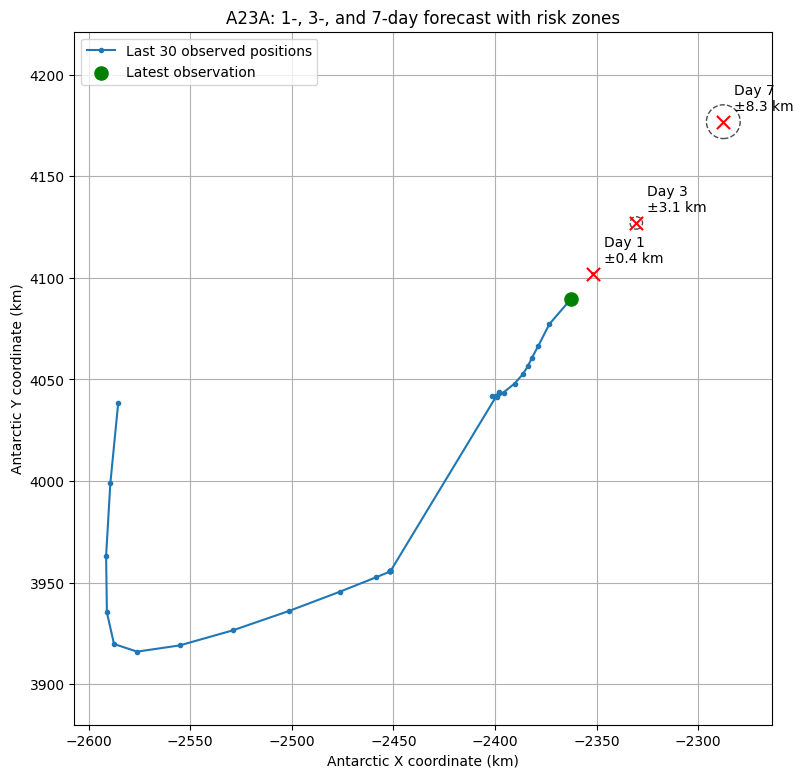

Saved: /content/a23a_mvp_forecast.csv
Saved: /content/a23a_mvp_validation_metrics.csv
Saved: /content/a23a_mvp_summary.json


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import json

MVP_ICEBERG = "A23A"
MVP_HORIZONS = [1, 3, 7]

# 1. Get empirical accuracy / uncertainty from the unseen 2020 A23A test set
mvp_metrics = []

for horizon in MVP_HORIZONS:
    test_set = trajectory_test_sets[horizon]

    mvp_metrics.append({
        "forecast_horizon_days": horizon,
        "selected_model": "constant_velocity",
        "mean_error_km": test_set["baseline_error_km"].mean(),
        "median_error_km": test_set["baseline_error_km"].median(),
        "risk_radius_km_p90": test_set["baseline_error_km"].quantile(0.90),
    })

mvp_metrics = pd.DataFrame(mvp_metrics)

# 2. Use the newest A23A observation in the historic dataset
a23_history = tracks[
    tracks["iceberg_id"] == MVP_ICEBERG
].sort_values("date").copy()

latest = a23_history.iloc[-1]
previous = a23_history.iloc[-2]

gap_days = (latest["date"] - previous["date"]).days

vx = (latest["x_m"] - previous["x_m"]) / gap_days
vy = (latest["y_m"] - previous["y_m"]) / gap_days

# 3. Make selected-model forecasts for 1, 3, and 7 days
forecast_rows = []

for horizon in MVP_HORIZONS:
    pred_x = latest["x_m"] + vx * horizon
    pred_y = latest["y_m"] + vy * horizon

    pred_lon, pred_lat = to_wgs84.transform(pred_x, pred_y)

    risk_radius = float(
        mvp_metrics.loc[
            mvp_metrics["forecast_horizon_days"] == horizon,
            "risk_radius_km_p90"
        ].iloc[0]
    )

    forecast_rows.append({
        "iceberg_id": MVP_ICEBERG,
        "latest_observation_date": latest["date"].date().isoformat(),
        "forecast_horizon_days": horizon,
        "forecast_date": (
            latest["date"] + pd.Timedelta(days=horizon)
        ).date().isoformat(),
        "predicted_latitude": pred_lat,
        "predicted_longitude": pred_lon,
        "risk_radius_km_p90": risk_radius,
        "selected_model": "constant_velocity",
    })

mvp_forecast = pd.DataFrame(forecast_rows)

print("Selected MVP model: Constant velocity")
print("Latest available A23A observation:", latest["date"].date())

display(mvp_metrics.round(3))
display(mvp_forecast.round(4))

# 4. Plot history, forecast waypoints, and 90% risk zones
recent = a23_history.tail(30)

plt.figure(figsize=(9, 9))

plt.plot(
    recent["x_m"] / 1000,
    recent["y_m"] / 1000,
    marker="o",
    markersize=3,
    label="Last 30 observed positions"
)

plt.scatter(
    latest["x_m"] / 1000,
    latest["y_m"] / 1000,
    color="green",
    s=90,
    zorder=5,
    label="Latest observation"
)

for _, row in mvp_forecast.iterrows():
    horizon = int(row["forecast_horizon_days"])

    pred_x = latest["x_m"] + vx * horizon
    pred_y = latest["y_m"] + vy * horizon

    plt.scatter(
        pred_x / 1000,
        pred_y / 1000,
        color="red",
        marker="x",
        s=90,
        zorder=5
    )

    risk_circle = Circle(
        (pred_x / 1000, pred_y / 1000),
        row["risk_radius_km_p90"],
        fill=False,
        linestyle="--",
        alpha=0.7
    )

    plt.gca().add_patch(risk_circle)

    plt.annotate(
        f"Day {horizon}\n±{row['risk_radius_km_p90']:.1f} km",
        (pred_x / 1000, pred_y / 1000),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.title("A23A: 1-, 3-, and 7-day forecast with risk zones")
plt.xlabel("Antarctic X coordinate (km)")
plt.ylabel("Antarctic Y coordinate (km)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# 5. Save MVP results
mvp_forecast.to_csv("/content/a23a_mvp_forecast.csv", index=False)
mvp_metrics.to_csv("/content/a23a_mvp_validation_metrics.csv", index=False)

with open("/content/a23a_mvp_summary.json", "w") as file:
    json.dump(
        {
            "iceberg_id": MVP_ICEBERG,
            "selected_model": "constant_velocity",
            "validation_period": "A23A unseen 2020 data",
            "forecast_horizons_days": MVP_HORIZONS,
            "notes": (
                "Risk radii use the empirical 90th-percentile positional "
                "error from held-out historical observations."
            ),
        },
        file,
        indent=2
    )

print("Saved: /content/a23a_mvp_forecast.csv")
print("Saved: /content/a23a_mvp_validation_metrics.csv")
print("Saved: /content/a23a_mvp_summary.json")

In [49]:
from google.colab import files

files.download("/content/a23a_mvp_forecast.csv")
files.download("/content/a23a_mvp_validation_metrics.csv")
files.download("/content/a23a_mvp_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
!pip -q install filterpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 17.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [51]:
# Import the libraries needed for the Kalman filter and evaluation
import numpy as np
import pandas as pd
from filterpy.kalman import KalmanFilter
from pyproj import Transformer

# Use A23A data in chronological order
kalman_data = a23_ml.copy().sort_values("date").reset_index(drop=True)

# We will test only on unseen 2020 dates
TEST_START = pd.Timestamp("2020-01-01")
TEST_END = pd.Timestamp("2020-12-31")

# We compare the same three forecast horizons as before
HORIZONS = [1, 3, 7]

# Converts Antarctica x/y metres back to latitude/longitude for km error
to_wgs84 = Transformer.from_crs(
    "EPSG:3031",
    "EPSG:4326",
    always_xy=True
)

# Function to calculate real geographical distance between two locations
def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0088

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    return 2 * earth_radius_km * np.arcsin(np.sqrt(a))


# This creates a new Kalman filter.
# State = [x position, y position, x velocity, y velocity]
def make_kalman_filter(start_x, start_y, start_vx, start_vy):
    kf = KalmanFilter(dim_x=4, dim_z=2)

    # Start position and velocity
    kf.x = np.array([
        start_x,
        start_y,
        start_vx,
        start_vy
    ], dtype=float)

    # One-day motion rule:
    # new position = old position + velocity
    # new velocity = old velocity
    kf.F = np.array([
        [1, 0, 1, 0],
        [0, 1, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ], dtype=float)

    # We observe only position from the satellite database
    kf.H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ], dtype=float)

    # Initial uncertainty:
    # position may be uncertain by about 1 km;
    # velocity may be uncertain by about 500 m/day.
    kf.P = np.diag([
        1000**2,
        1000**2,
        500**2,
        500**2
    ])

    # Measurement uncertainty:
    # iceberg position observations are not perfectly exact.
    kf.R = np.diag([
        500**2,
        500**2
    ])

    # Process uncertainty:
    # icebergs can accelerate/turn, so velocity is allowed to change.
    acceleration_variance = 800**2

    q = np.array([
        [0.25, 0.0, 0.5, 0.0],
        [0.0, 0.25, 0.0, 0.5],
        [0.5, 0.0, 1.0, 0.0],
        [0.0, 0.5, 0.0, 1.0]
    ], dtype=float)

    kf.Q = q * acceleration_variance

    return kf


# Store actual historical locations by date.
# This lets us compare forecasts to the known future location.
actual_positions = kalman_data.set_index("date")[["x_m", "y_m"]]

# This list will contain every Kalman prediction and its error
kalman_predictions = []

kf = None
previous_date = None

# Walk through A23A's timeline in order:
# the filter is allowed to use only current and past observations.
for _, row in kalman_data.iterrows():
    current_date = row["date"]

    # If this is the first point, start a new Kalman filter.
    # Also reset if there is a gap in observations.
    if (
        kf is None
        or previous_date is None
        or (current_date - previous_date).days != 1
    ):
        kf = make_kalman_filter(
            row["x_m"],
            row["y_m"],
            row["vx_m_per_day"],
            row["vy_m_per_day"]
        )
    else:
        # Predict today's state using yesterday's state
        kf.predict()

        # Correct that prediction using today's observed iceberg position
        kf.update(
            np.array([
                row["x_m"],
                row["y_m"]
            ])
        )

    # After seeing today's position, forecast 1, 3, and 7 days ahead.
    for horizon in HORIZONS:
        future_date = current_date + pd.Timedelta(days=horizon)

        # Skip dates outside the 2020 held-out test period
        if (
            current_date < TEST_START
            or future_date > TEST_END
            or future_date not in actual_positions.index
        ):
            continue

        # Apply the one-day movement rule N times
        future_transition = np.linalg.matrix_power(kf.F, horizon)
        predicted_state = future_transition @ kf.x

        pred_x = predicted_state[0]
        pred_y = predicted_state[1]

        actual_x = actual_positions.loc[future_date, "x_m"]
        actual_y = actual_positions.loc[future_date, "y_m"]

        # Convert both points to latitude/longitude for error in km
        pred_lon, pred_lat = to_wgs84.transform(pred_x, pred_y)
        actual_lon, actual_lat = to_wgs84.transform(actual_x, actual_y)

        error_km = haversine_km(
            actual_lat,
            actual_lon,
            pred_lat,
            pred_lon
        )

        kalman_predictions.append({
            "forecast_date": current_date,
            "horizon_days": horizon,
            "actual_date": future_date,
            "kalman_error_km": error_km
        })

    previous_date = current_date

# Turn all prediction records into a table
kalman_predictions = pd.DataFrame(kalman_predictions)

# Final Kalman accuracy table
kalman_results = (
    kalman_predictions
    .groupby("horizon_days")["kalman_error_km"]
    .agg(
        test_examples="count",
        mean_error_km="mean",
        median_error_km="median",
        p90_error_km=lambda values: values.quantile(0.90)
    )
    .reset_index()
)

display(kalman_results.round(3))

,horizon_days,test_examples,mean_error_km,median_error_km,p90_error_km
0,1,365,0.331,0.055,0.813
1,3,363,1.240,0.284,3.638
2,7,359,3.664,1.609,9.509


A23A Random Forest: train on 2018–2019; test on unseen 2020


,Forecast horizon,Test examples,Baseline mean error (km),Random Forest mean error (km),Random Forest median error (km),Random Forest p90 error (km)
0,1 day,365,0.249,1.061,0.290,4.339
1,3 day,363,1.116,3.535,1.136,10.514
2,7 day,359,3.497,4.629,2.101,12.457


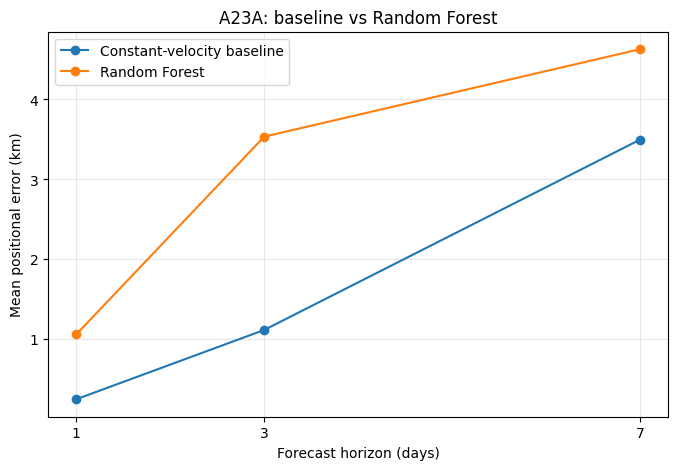

In [52]:
from sklearn.ensemble import RandomForestRegressor
from pyproj import Transformer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare A23A features
# ------------------------------------------------------------
rf_data = a23_ml.copy().sort_values("date").reset_index(drop=True)

# Turn the day of year into circular seasonal features.
# December and January should be considered close together.
rf_data["day_of_year"] = rf_data["date"].dt.dayofyear
rf_data["day_sin"] = np.sin(
    2 * np.pi * rf_data["day_of_year"] / 365.25
)
rf_data["day_cos"] = np.cos(
    2 * np.pi * rf_data["day_of_year"] / 365.25
)

# Approximate area when length and width are available.
rf_data["area_proxy_nm2"] = (
    rf_data["length_nm"] * rf_data["width_nm"]
)

# Inputs that Random Forest is allowed to use.
RF_FEATURES = [
    "x_m",
    "y_m",
    "vx_m_per_day",
    "vy_m_per_day",
    "u10_m_per_s",
    "v10_m_per_s",
    "uo_m_per_s",
    "vo_m_per_s",
    "day_sin",
    "day_cos",
    "length_nm",
    "width_nm",
    "area_proxy_nm2",
]

# Convert Antarctica x/y coordinates back to lat/lon for km error.
to_wgs84 = Transformer.from_crs(
    "EPSG:3031",
    "EPSG:4326",
    always_xy=True
)

# Same fair horizons and test period as Kalman/XGBoost.
HORIZONS = [1, 3, 7]

rf_models = {}
rf_test_sets = {}
rf_result_rows = []

# ------------------------------------------------------------
# 2. Train one direct Random Forest pair per useful horizon
# ------------------------------------------------------------
for days_ahead in HORIZONS:
    data = rf_data.copy()

    # Get the real location exactly N days later.
    data["future_x_m"] = data["x_m"].shift(-days_ahead)
    data["future_y_m"] = data["y_m"].shift(-days_ahead)
    data["future_date"] = data["date"].shift(-days_ahead)

    # Keep only continuous daily sequences.
    data = data[
        (data["previous_gap_days"] == 1) &
        ((data["future_date"] - data["date"]).dt.days == days_ahead)
    ].copy()

    # Baseline forecast: continue at the latest measured velocity.
    data["baseline_x_m"] = (
        data["x_m"] + data["vx_m_per_day"] * days_ahead
    )
    data["baseline_y_m"] = (
        data["y_m"] + data["vy_m_per_day"] * days_ahead
    )

    # Random Forest learns only the correction beyond the baseline.
    data["residual_dx_m"] = (
        data["future_x_m"] - data["baseline_x_m"]
    )
    data["residual_dy_m"] = (
        data["future_y_m"] - data["baseline_y_m"]
    )

    # Fair split:
    # train with 2018–2019 only;
    # test on unseen 2020 dates only.
    train = data[data["future_date"] < "2020-01-01"].copy()
    test = data[
        (data["date"] >= "2020-01-01") &
        (data["future_date"] <= "2020-12-31")
    ].copy()

    # Random Forest cannot safely use missing values in every Colab version.
    # Fill missing size fields using medians from training data only.
    feature_medians = train[RF_FEATURES].median()

    X_train = train[RF_FEATURES].fillna(feature_medians)
    X_test = test[RF_FEATURES].fillna(feature_medians)

    # East/west correction model.
    rf_dx = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1,
        random_state=42,
    )

    # North/south correction model.
    rf_dy = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        max_features=0.8,
        n_jobs=-1,
        random_state=42,
    )

    rf_dx.fit(X_train, train["residual_dx_m"])
    rf_dy.fit(X_train, train["residual_dy_m"])

    # Final RF forecast = baseline forecast + RF correction.
    test["rf_pred_x_m"] = (
        test["baseline_x_m"] + rf_dx.predict(X_test)
    )
    test["rf_pred_y_m"] = (
        test["baseline_y_m"] + rf_dy.predict(X_test)
    )

    # Convert actual, baseline, and RF points to lat/lon.
    actual_lon, actual_lat = to_wgs84.transform(
        test["future_x_m"].to_numpy(),
        test["future_y_m"].to_numpy()
    )

    baseline_lon, baseline_lat = to_wgs84.transform(
        test["baseline_x_m"].to_numpy(),
        test["baseline_y_m"].to_numpy()
    )

    rf_lon, rf_lat = to_wgs84.transform(
        test["rf_pred_x_m"].to_numpy(),
        test["rf_pred_y_m"].to_numpy()
    )

    # Calculate real geographical error in kilometres.
    test["baseline_error_km"] = haversine_km(
        actual_lat, actual_lon,
        baseline_lat, baseline_lon
    )

    test["rf_error_km"] = haversine_km(
        actual_lat, actual_lon,
        rf_lat, rf_lon
    )

    # Store models and test results.
    rf_models[days_ahead] = {
        "dx": rf_dx,
        "dy": rf_dy,
        "feature_medians": feature_medians,
    }

    rf_test_sets[days_ahead] = test

    rf_result_rows.append({
        "Forecast horizon": f"{days_ahead} day",
        "Test examples": len(test),
        "Baseline mean error (km)": test["baseline_error_km"].mean(),
        "Random Forest mean error (km)": test["rf_error_km"].mean(),
        "Random Forest median error (km)": test["rf_error_km"].median(),
        "Random Forest p90 error (km)": test["rf_error_km"].quantile(0.90),
    })

# ------------------------------------------------------------
# 3. Show results
# ------------------------------------------------------------
rf_results = pd.DataFrame(rf_result_rows)

print("A23A Random Forest: train on 2018–2019; test on unseen 2020")
display(rf_results.round(3))

plt.figure(figsize=(8, 5))

plt.plot(
    HORIZONS,
    rf_results["Baseline mean error (km)"],
    marker="o",
    label="Constant-velocity baseline"
)

plt.plot(
    HORIZONS,
    rf_results["Random Forest mean error (km)"],
    marker="o",
    label="Random Forest"
)

plt.xticks(HORIZONS)
plt.xlabel("Forecast horizon (days)")
plt.ylabel("Mean positional error (km)")
plt.title("A23A: baseline vs Random Forest")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

,Forecast horizon,Model,Test examples,Mean error (km),Median error (km),90th percentile error (km)
0,1 day,Constant velocity baseline,365,0.249,0.033,0.437
1,1 day,Kalman filter,365,0.331,0.055,0.813
2,1 day,Random Forest,365,1.061,0.290,4.339
3,1 day,Wind + current XGBoost,365,1.758,1.273,4.466
4,3 day,Constant velocity baseline,363,1.116,0.180,3.061
5,3 day,Kalman filter,363,1.240,0.284,3.638
6,3 day,Random Forest,363,3.535,1.136,10.514
7,3 day,Wind + current XGBoost,363,5.818,3.424,13.251
8,7 day,Constant velocity baseline,359,3.497,1.461,8.308
9,7 day,Kalman filter,359,3.664,1.609,9.509


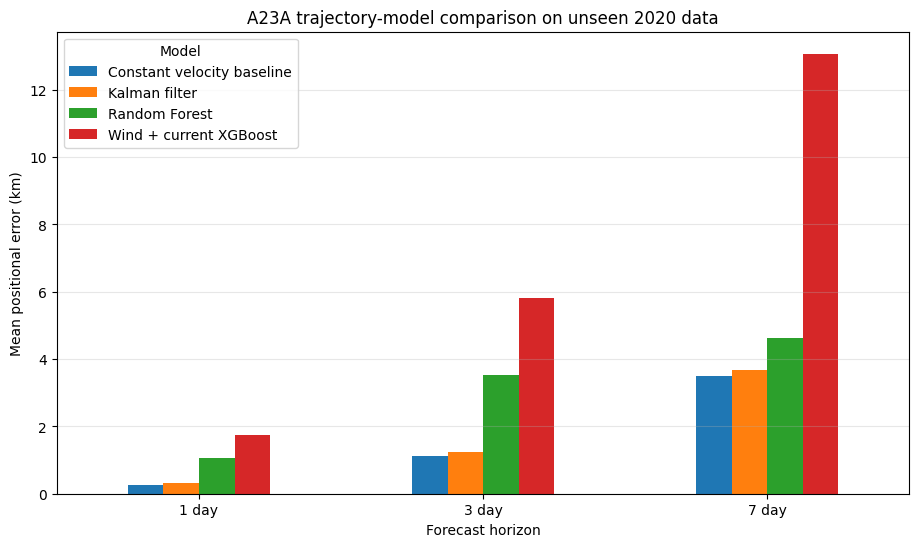

Saved: /content/a23a_all_model_comparison.csv


In [53]:
final_comparison_rows = []

for horizon in HORIZONS:
    # Baseline and Random Forest errors
    rf_test = rf_test_sets[horizon]

    # Wind + current XGBoost errors
    xgb_test = trajectory_test_sets[horizon]

    # Kalman errors
    kalman_test = kalman_predictions[
        kalman_predictions["horizon_days"] == horizon
    ]

    models_and_errors = {
        "Constant velocity baseline": rf_test["baseline_error_km"],
        "Kalman filter": kalman_test["kalman_error_km"],
        "Random Forest": rf_test["rf_error_km"],
        "Wind + current XGBoost": xgb_test["model_error_km"],
    }

    for model_name, errors in models_and_errors.items():
        final_comparison_rows.append({
            "Forecast horizon": f"{horizon} day",
            "Model": model_name,
            "Test examples": len(errors),
            "Mean error (km)": errors.mean(),
            "Median error (km)": errors.median(),
            "90th percentile error (km)": errors.quantile(0.90),
        })

final_comparison = pd.DataFrame(final_comparison_rows)

display(
    final_comparison
    .sort_values(["Forecast horizon", "Mean error (km)"])
    .round(3)
)

# Clear visual comparison of mean error
pivot_mean = final_comparison.pivot(
    index="Forecast horizon",
    columns="Model",
    values="Mean error (km)"
).reindex(["1 day", "3 day", "7 day"])

pivot_mean.plot(
    kind="bar",
    figsize=(11, 6),
    title="A23A trajectory-model comparison on unseen 2020 data"
)

plt.ylabel("Mean positional error (km)")
plt.xlabel("Forecast horizon")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Model")
plt.show()

final_comparison.to_csv(
    "/content/a23a_all_model_comparison.csv",
    index=False
)

print("Saved: /content/a23a_all_model_comparison.csv")

In [54]:
from google.colab import files

files.download("/content/a23a_all_model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,iceberg_id,latest_observation_date,forecast_horizon_days,forecast_date,predicted_latitude,predicted_longitude,mean_validation_error_km,risk_radius_km_p90,selected_model
0,A23A,2026-03-31,1,2026-04-01,-48.3440,-29.8273,0.2487,0.4373,constant_velocity_baseline
1,A23A,2026-03-31,3,2026-04-03,-48.2546,-29.4529,1.1156,3.0609,constant_velocity_baseline
2,A23A,2026-03-31,7,2026-04-07,-48.0711,-28.7094,3.4970,8.3081,constant_velocity_baseline


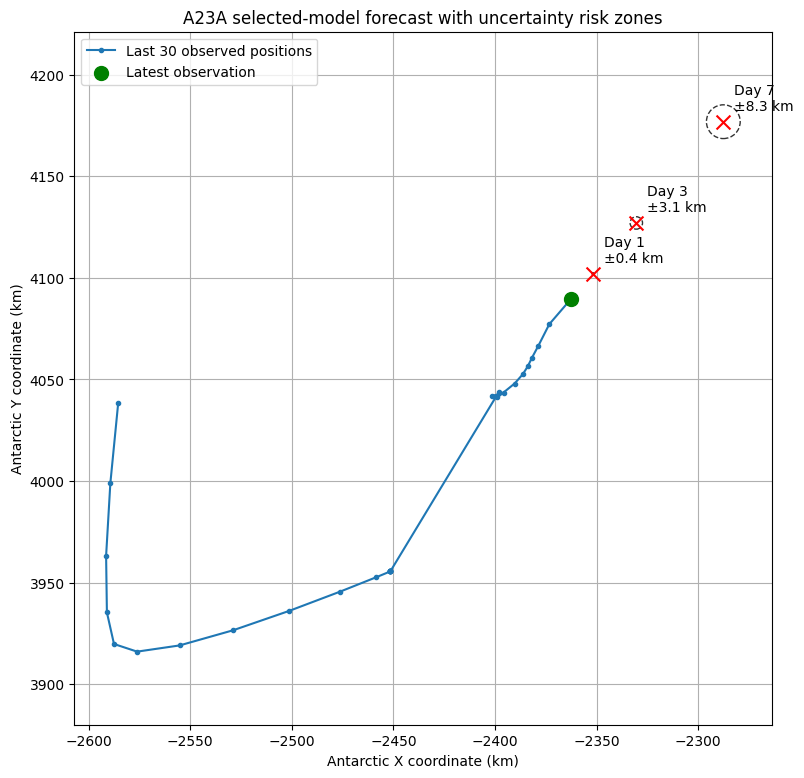

Saved: /content/a23a_selected_model_forecast.csv
Saved: /content/a23a_selected_model_metrics.csv


In [55]:
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SELECTED_ICEBERG = "A23A"
HORIZONS = [1, 3, 7]

# Get baseline validation accuracy for each horizon
selected_metrics = final_comparison[
    final_comparison["Model"] == "Constant velocity baseline"
].copy()

selected_metrics["forecast_horizon_days"] = (
    selected_metrics["Forecast horizon"]
    .str.replace(" day", "", regex=False)
    .astype(int)
)

# Latest known A23A movement
history = tracks[
    tracks["iceberg_id"] == SELECTED_ICEBERG
].sort_values("date").copy()

latest = history.iloc[-1]
previous = history.iloc[-2]

gap_days = (latest["date"] - previous["date"]).days

vx = (latest["x_m"] - previous["x_m"]) / gap_days
vy = (latest["y_m"] - previous["y_m"]) / gap_days

forecast_rows = []

for horizon in HORIZONS:
    predicted_x = latest["x_m"] + vx * horizon
    predicted_y = latest["y_m"] + vy * horizon

    predicted_lon, predicted_lat = to_wgs84.transform(
        predicted_x,
        predicted_y
    )

    metric_row = selected_metrics[
        selected_metrics["forecast_horizon_days"] == horizon
    ].iloc[0]

    forecast_rows.append({
        "iceberg_id": SELECTED_ICEBERG,
        "latest_observation_date": latest["date"].date().isoformat(),
        "forecast_horizon_days": horizon,
        "forecast_date": (
            latest["date"] + pd.Timedelta(days=horizon)
        ).date().isoformat(),
        "predicted_latitude": predicted_lat,
        "predicted_longitude": predicted_lon,
        "mean_validation_error_km": metric_row["Mean error (km)"],
        "risk_radius_km_p90": metric_row["90th percentile error (km)"],
        "selected_model": "constant_velocity_baseline",
    })

final_forecast = pd.DataFrame(forecast_rows)

display(final_forecast.round(4))

# Plot latest history, forecast points, and uncertainty/risk circles
recent = history.tail(30)

plt.figure(figsize=(9, 9))

plt.plot(
    recent["x_m"] / 1000,
    recent["y_m"] / 1000,
    marker="o",
    markersize=3,
    label="Last 30 observed positions"
)

plt.scatter(
    latest["x_m"] / 1000,
    latest["y_m"] / 1000,
    color="green",
    s=100,
    zorder=5,
    label="Latest observation"
)

for _, row in final_forecast.iterrows():
    horizon = int(row["forecast_horizon_days"])

    pred_x = latest["x_m"] + vx * horizon
    pred_y = latest["y_m"] + vy * horizon

    plt.scatter(
        pred_x / 1000,
        pred_y / 1000,
        color="red",
        marker="x",
        s=100,
        zorder=5
    )

    plt.gca().add_patch(
        Circle(
            (pred_x / 1000, pred_y / 1000),
            row["risk_radius_km_p90"],
            fill=False,
            linestyle="--",
            alpha=0.8
        )
    )

    plt.annotate(
        f"Day {horizon}\n±{row['risk_radius_km_p90']:.1f} km",
        (pred_x / 1000, pred_y / 1000),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.title("A23A selected-model forecast with uncertainty risk zones")
plt.xlabel("Antarctic X coordinate (km)")
plt.ylabel("Antarctic Y coordinate (km)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

final_forecast.to_csv(
    "/content/a23a_selected_model_forecast.csv",
    index=False
)

selected_metrics.to_csv(
    "/content/a23a_selected_model_metrics.csv",
    index=False
)

print("Saved: /content/a23a_selected_model_forecast.csv")
print("Saved: /content/a23a_selected_model_metrics.csv")

In [56]:
import numpy as np
import pandas as pd

# Evaluate complete 7-day forecast windows in the unseen 2020 test period
ade_fde_rows = []

a23_eval = a23_ml.copy().sort_values("date").reset_index(drop=True)
actual_by_date = a23_eval.set_index("date")[["x_m", "y_m"]]

for _, row in a23_eval.iterrows():
    start_date = row["date"]
    final_date = start_date + pd.Timedelta(days=7)

    # Use only 2020 forecasts with all seven future actual positions known
    if (
        start_date < pd.Timestamp("2020-01-01")
        or final_date > pd.Timestamp("2020-12-31")
    ):
        continue

    daily_errors = []

    for horizon in range(1, 8):
        target_date = start_date + pd.Timedelta(days=horizon)

        if target_date not in actual_by_date.index:
            daily_errors = []
            break

        # Constant-velocity predicted position
        pred_x = row["x_m"] + row["vx_m_per_day"] * horizon
        pred_y = row["y_m"] + row["vy_m_per_day"] * horizon

        actual_x = actual_by_date.loc[target_date, "x_m"]
        actual_y = actual_by_date.loc[target_date, "y_m"]

        pred_lon, pred_lat = to_wgs84.transform(pred_x, pred_y)
        actual_lon, actual_lat = to_wgs84.transform(actual_x, actual_y)

        error_km = haversine_km(
            actual_lat, actual_lon,
            pred_lat, pred_lon
        )

        daily_errors.append(error_km)

    if len(daily_errors) == 7:
        ade_fde_rows.append({
            "forecast_start_date": start_date,
            "ADE_7_day_km": np.mean(daily_errors),
            "FDE_7_day_km": daily_errors[-1],
        })

ade_fde = pd.DataFrame(ade_fde_rows)

ade_fde_summary = pd.DataFrame([{
    "Model": "Constant velocity baseline",
    "Forecast windows": len(ade_fde),
    "Mean ADE over 7 days (km)": ade_fde["ADE_7_day_km"].mean(),
    "Mean FDE at Day 7 (km)": ade_fde["FDE_7_day_km"].mean(),
    "Median FDE at Day 7 (km)": ade_fde["FDE_7_day_km"].median(),
    "90th percentile FDE (km)": ade_fde["FDE_7_day_km"].quantile(0.90),
}])

display(ade_fde_summary.round(3))

ade_fde.to_csv("/content/a23a_ade_fde_per_forecast.csv", index=False)
ade_fde_summary.to_csv("/content/a23a_ade_fde_summary.csv", index=False)

print("Saved ADE/FDE files in /content.")

,Model,Forecast windows,Mean ADE over 7 days (km),Mean FDE at Day 7 (km),Median FDE at Day 7 (km),90th percentile FDE (km)
0,Constant velocity baseline,359,1.751,3.497,1.461,8.308


Saved ADE/FDE files in /content.


In [57]:
import numpy as np
import pandas as pd

# Evaluate complete 7-day forecast windows in the unseen 2020 test period
ade_fde_rows = []

a23_eval = a23_ml.copy().sort_values("date").reset_index(drop=True)
actual_by_date = a23_eval.set_index("date")[["x_m", "y_m"]]

for _, row in a23_eval.iterrows():
    start_date = row["date"]
    final_date = start_date + pd.Timedelta(days=7)

    # Use only 2020 forecasts with all seven future actual positions known
    if (
        start_date < pd.Timestamp("2020-01-01")
        or final_date > pd.Timestamp("2020-12-31")
    ):
        continue

    daily_errors = []

    for horizon in range(1, 8):
        target_date = start_date + pd.Timedelta(days=horizon)

        if target_date not in actual_by_date.index:
            daily_errors = []
            break

        # Constant-velocity predicted position
        pred_x = row["x_m"] + row["vx_m_per_day"] * horizon
        pred_y = row["y_m"] + row["vy_m_per_day"] * horizon

        actual_x = actual_by_date.loc[target_date, "x_m"]
        actual_y = actual_by_date.loc[target_date, "y_m"]

        pred_lon, pred_lat = to_wgs84.transform(pred_x, pred_y)
        actual_lon, actual_lat = to_wgs84.transform(actual_x, actual_y)

        error_km = haversine_km(
            actual_lat, actual_lon,
            pred_lat, pred_lon
        )

        daily_errors.append(error_km)

    if len(daily_errors) == 7:
        ade_fde_rows.append({
            "forecast_start_date": start_date,
            "ADE_7_day_km": np.mean(daily_errors),
            "FDE_7_day_km": daily_errors[-1],
        })

ade_fde = pd.DataFrame(ade_fde_rows)

ade_fde_summary = pd.DataFrame([{
    "Model": "Constant velocity baseline",
    "Forecast windows": len(ade_fde),
    "Mean ADE over 7 days (km)": ade_fde["ADE_7_day_km"].mean(),
    "Mean FDE at Day 7 (km)": ade_fde["FDE_7_day_km"].mean(),
    "Median FDE at Day 7 (km)": ade_fde["FDE_7_day_km"].median(),
    "90th percentile FDE (km)": ade_fde["FDE_7_day_km"].quantile(0.90),
}])

display(ade_fde_summary.round(3))

ade_fde.to_csv("/content/a23a_ade_fde_per_forecast.csv", index=False)
ade_fde_summary.to_csv("/content/a23a_ade_fde_summary.csv", index=False)

print("Saved ADE/FDE files in /content.")

,Model,Forecast windows,Mean ADE over 7 days (km),Mean FDE at Day 7 (km),Median FDE at Day 7 (km),90th percentile FDE (km)
0,Constant velocity baseline,359,1.751,3.497,1.461,8.308


Saved ADE/FDE files in /content.


Latest A23A observation: 2026-03-31
Selected model: Constant velocity baseline

Forecast:


,iceberg_id,selected_model,latest_observation_date,forecast_horizon_days,forecast_date,predicted_latitude,predicted_longitude,mean_validation_error_km,risk_radius_km_p90
0,A23A,constant_velocity_baseline,2026-03-31,1,2026-04-01,-48.3440,-29.8273,0.2487,0.4373
1,A23A,constant_velocity_baseline,2026-03-31,3,2026-04-03,-48.2546,-29.4529,1.1156,3.0609
2,A23A,constant_velocity_baseline,2026-03-31,7,2026-04-07,-48.0711,-28.7094,3.4970,8.3081



Validation metrics:


,Forecast horizon,Model,Test examples,Mean error (km),Median error (km),90th percentile error (km),forecast_horizon_days,Mean ADE over 7 days (km),Mean FDE at Day 7 (km)
0,1 day,Constant velocity baseline,365,0.249,0.033,0.437,1,NaN,NaN
1,3 day,Constant velocity baseline,363,1.116,0.180,3.061,3,NaN,NaN
2,7 day,Constant velocity baseline,359,3.497,1.461,8.308,7,1.751,3.497


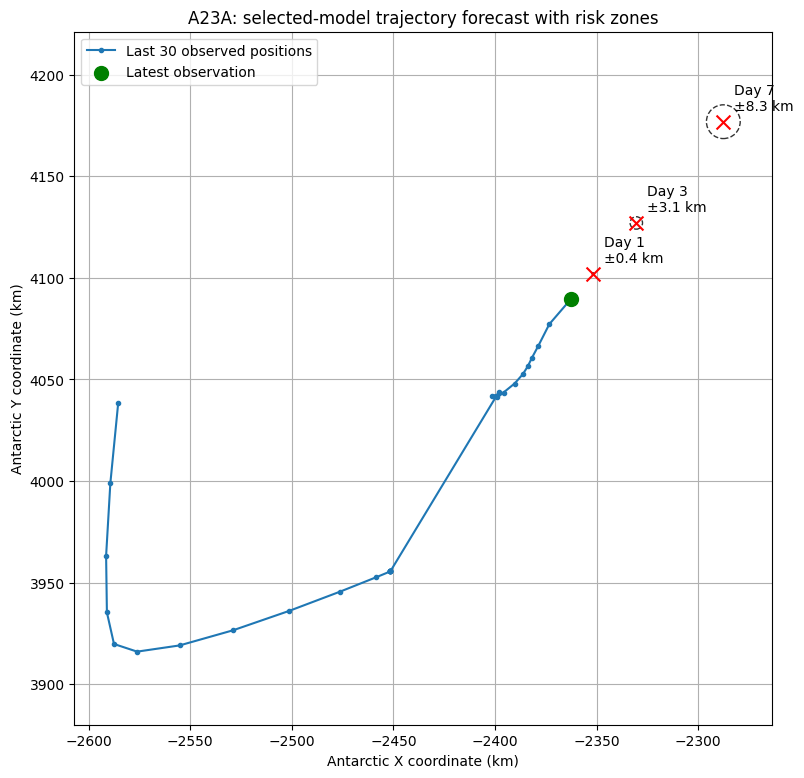


Saved files:
/content/a23a_final_forecast.csv
/content/a23a_final_validation_metrics.csv
/content/a23a_final_summary.json


In [58]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

SELECTED_ICEBERG = "A23A"
HORIZONS = [1, 3, 7]

# ------------------------------------------------------------
# 1. Selected model = constant-velocity baseline
# ------------------------------------------------------------
selected_metrics = final_comparison[
    final_comparison["Model"] == "Constant velocity baseline"
].copy()

selected_metrics["forecast_horizon_days"] = (
    selected_metrics["Forecast horizon"]
    .str.replace(" day", "", regex=False)
    .astype(int)
)

selected_metrics = selected_metrics.sort_values(
    "forecast_horizon_days"
).reset_index(drop=True)

# Add ADE/FDE only to the 7-day validation row
selected_metrics["Mean ADE over 7 days (km)"] = np.nan
selected_metrics["Mean FDE at Day 7 (km)"] = np.nan

selected_metrics.loc[
    selected_metrics["forecast_horizon_days"] == 7,
    "Mean ADE over 7 days (km)"
] = ade_fde_summary["Mean ADE over 7 days (km)"].iloc[0]

selected_metrics.loc[
    selected_metrics["forecast_horizon_days"] == 7,
    "Mean FDE at Day 7 (km)"
] = ade_fde_summary["Mean FDE at Day 7 (km)"].iloc[0]

# ------------------------------------------------------------
# 2. Find latest A23A observation and movement
# ------------------------------------------------------------
history = tracks[
    tracks["iceberg_id"] == SELECTED_ICEBERG
].sort_values("date").copy()

latest = history.iloc[-1]
previous = history.iloc[-2]

gap_days = (latest["date"] - previous["date"]).days

vx_m_per_day = (latest["x_m"] - previous["x_m"]) / gap_days
vy_m_per_day = (latest["y_m"] - previous["y_m"]) / gap_days

# ------------------------------------------------------------
# 3. Make 1-, 3-, and 7-day forecast points
# ------------------------------------------------------------
forecast_rows = []

for horizon in HORIZONS:
    predicted_x = latest["x_m"] + vx_m_per_day * horizon
    predicted_y = latest["y_m"] + vy_m_per_day * horizon

    predicted_lon, predicted_lat = to_wgs84.transform(
        predicted_x,
        predicted_y
    )

    metric_row = selected_metrics[
        selected_metrics["forecast_horizon_days"] == horizon
    ].iloc[0]

    forecast_rows.append({
        "iceberg_id": SELECTED_ICEBERG,
        "selected_model": "constant_velocity_baseline",
        "latest_observation_date": latest["date"].date().isoformat(),
        "forecast_horizon_days": horizon,
        "forecast_date": (
            latest["date"] + pd.Timedelta(days=horizon)
        ).date().isoformat(),
        "predicted_latitude": predicted_lat,
        "predicted_longitude": predicted_lon,
        "mean_validation_error_km": metric_row["Mean error (km)"],
        "risk_radius_km_p90": metric_row[
            "90th percentile error (km)"
        ],
    })

final_forecast = pd.DataFrame(forecast_rows)

print("Latest A23A observation:", latest["date"].date())
print("Selected model: Constant velocity baseline")

print("\nForecast:")
display(final_forecast.round(4))

print("\nValidation metrics:")
display(selected_metrics.round(3))

# ------------------------------------------------------------
# 4. Plot observations, forecast points, and risk circles
# ------------------------------------------------------------
recent = history.tail(30)

plt.figure(figsize=(9, 9))

plt.plot(
    recent["x_m"] / 1000,
    recent["y_m"] / 1000,
    marker="o",
    markersize=3,
    label="Last 30 observed positions"
)

plt.scatter(
    latest["x_m"] / 1000,
    latest["y_m"] / 1000,
    color="green",
    s=100,
    zorder=5,
    label="Latest observation"
)

for _, row in final_forecast.iterrows():
    horizon = int(row["forecast_horizon_days"])

    pred_x = latest["x_m"] + vx_m_per_day * horizon
    pred_y = latest["y_m"] + vy_m_per_day * horizon

    plt.scatter(
        pred_x / 1000,
        pred_y / 1000,
        color="red",
        marker="x",
        s=100,
        zorder=5
    )

    # Circle radius uses held-out 90th-percentile error
    plt.gca().add_patch(
        Circle(
            (pred_x / 1000, pred_y / 1000),
            row["risk_radius_km_p90"],
            fill=False,
            linestyle="--",
            alpha=0.8
        )
    )

    plt.annotate(
        f"Day {horizon}\n±{row['risk_radius_km_p90']:.1f} km",
        (pred_x / 1000, pred_y / 1000),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.title("A23A: selected-model trajectory forecast with risk zones")
plt.xlabel("Antarctic X coordinate (km)")
plt.ylabel("Antarctic Y coordinate (km)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 5. Save final project outputs
# ------------------------------------------------------------
final_forecast.to_csv(
    "/content/a23a_final_forecast.csv",
    index=False
)

selected_metrics.to_csv(
    "/content/a23a_final_validation_metrics.csv",
    index=False
)

summary = {
    "iceberg_id": SELECTED_ICEBERG,
    "selected_model": "constant_velocity_baseline",
    "forecast_horizons_days": HORIZONS,
    "validation_period": "A23A unseen 2020 data",
    "seven_day_ADE_km": float(
        ade_fde_summary["Mean ADE over 7 days (km)"].iloc[0]
    ),
    "seven_day_FDE_km": float(
        ade_fde_summary["Mean FDE at Day 7 (km)"].iloc[0]
    ),
    "note": (
        "Risk radius uses empirical 90th-percentile held-out "
        "positional error for each forecast horizon."
    )
}

with open("/content/a23a_final_summary.json", "w") as file:
    json.dump(summary, file, indent=2)

print("\nSaved files:")
print("/content/a23a_final_forecast.csv")
print("/content/a23a_final_validation_metrics.csv")
print("/content/a23a_final_summary.json")

In [59]:
from pyproj import Transformer
import pandas as pd
import numpy as np

GLOBAL_HORIZONS = [1, 3, 7]

# Global held-out accuracy from your earlier 640-iceberg evaluation
global_metrics = final_metrics.copy()

global_metrics["forecast_horizon_days"] = (
    global_metrics["Forecast horizon"]
    .str.replace(" day", "", regex=False)
    .astype(int)
)

# Risk radius for each horizon:
# use global 90th-percentile error, not A23A-specific error
risk_by_horizon = {
    int(row["forecast_horizon_days"]): float(
        row["90th percentile (km)"]
    )
    for _, row in global_metrics.iterrows()
}

to_wgs84 = Transformer.from_crs(
    "EPSG:3031",
    "EPSG:4326",
    always_xy=True
)

def forecast_one_iceberg(track, horizons=[1, 3, 7]):
    """
    Input: one iceberg's historic positions.
    Output: 1-, 3-, and 7-day baseline forecast rows.
    """

    track = track.sort_values("date").copy()

    # Need at least two positions to calculate latest movement
    if len(track) < 2:
        return []

    latest = track.iloc[-1]
    previous = track.iloc[-2]

    gap_days = (latest["date"] - previous["date"]).days

    # Ignore invalid/non-forward date gaps
    if gap_days <= 0:
        return []

    # Latest movement in Antarctic metres per day
    vx = (latest["x_m"] - previous["x_m"]) / gap_days
    vy = (latest["y_m"] - previous["y_m"]) / gap_days

    rows = []

    for horizon in horizons:
        predicted_x = latest["x_m"] + vx * horizon
        predicted_y = latest["y_m"] + vy * horizon

        predicted_lon, predicted_lat = to_wgs84.transform(
            predicted_x,
            predicted_y
        )

        rows.append({
            "iceberg_id": latest["iceberg_id"],
            "latest_observation_date": latest["date"].date().isoformat(),
            "forecast_horizon_days": horizon,
            "forecast_date": (
                latest["date"] + pd.Timedelta(days=horizon)
            ).date().isoformat(),
            "predicted_latitude": predicted_lat,
            "predicted_longitude": predicted_lon,
            "latest_speed_m_per_day": float(np.hypot(vx, vy)),
            "risk_radius_km_p90": risk_by_horizon[horizon],
            "selected_model": "global_constant_velocity_baseline",
            "forecast_status": "historical_demo_not_real_time",
        })

    return rows


# Apply the same predictor to every iceberg track
global_forecast_rows = []

for iceberg_id, track in tracks.groupby("iceberg_id"):
    global_forecast_rows.extend(
        forecast_one_iceberg(track, GLOBAL_HORIZONS)
    )

global_forecast = pd.DataFrame(global_forecast_rows)

print("Icebergs forecasted:", global_forecast["iceberg_id"].nunique())
print("Forecast rows:", len(global_forecast))

display(
    global_forecast
    .sort_values(["latest_observation_date", "iceberg_id"])
    .tail(20)
    .round(4)
)

# Save outputs for your teammates / backend
global_forecast.to_csv(
    "/content/global_iceberg_trajectory_forecasts.csv",
    index=False
)

global_metrics.to_csv(
    "/content/global_trajectory_validation_metrics.csv",
    index=False
)

print("Saved: /content/global_iceberg_trajectory_forecasts.csv")
print("Saved: /content/global_trajectory_validation_metrics.csv")

Icebergs forecasted: 625
Forecast rows: 1875


,iceberg_id,latest_observation_date,forecast_horizon_days,forecast_date,predicted_latitude,predicted_longitude,latest_speed_m_per_day,risk_radius_km_p90,selected_model,forecast_status
1084,D34,2026-04-22,3,2026-04-25,-67.1115,81.9267,0.0000,11.9847,global_constant_velocity_baseline,historical_demo_not_real_time
1085,D34,2026-04-22,7,2026-04-29,-67.1115,81.9267,0.0000,38.8832,global_constant_velocity_baseline,historical_demo_not_real_time
1086,D35,2026-04-22,1,2026-04-23,-65.2479,-48.7613,4945.3519,2.5605,global_constant_velocity_baseline,historical_demo_not_real_time
1087,D35,2026-04-22,3,2026-04-25,-65.1637,-48.7092,4945.3519,11.9847,global_constant_velocity_baseline,historical_demo_not_real_time
1088,D35,2026-04-22,7,2026-04-29,-64.9953,-48.6060,4945.3519,38.8832,global_constant_velocity_baseline,historical_demo_not_real_time
1089,D36,2026-04-22,1,2026-04-23,-66.2589,86.7910,0.0000,2.5605,global_constant_velocity_baseline,historical_demo_not_real_time
1090,D36,2026-04-22,3,2026-04-25,-66.2589,86.7910,0.0000,11.9847,global_constant_velocity_baseline,historical_demo_not_real_time
1091,D36,2026-04-22,7,2026-04-29,-66.2589,86.7910,0.0000,38.8832,global_constant_velocity_baseline,historical_demo_not_real_time
1092,D37,2026-04-22,1,2026-04-23,-69.2140,36.3460,0.0000,2.5605,global_constant_velocity_baseline,historical_demo_not_real_time
1093,D37,2026-04-22,3,2026-04-25,-69.2140,36.3460,0.0000,11.9847,global_constant_velocity_baseline,historical_demo_not_real_time


Saved: /content/global_iceberg_trajectory_forecasts.csv
Saved: /content/global_trajectory_validation_metrics.csv


,Forecast horizon,Test examples,Mean error (km),Median error (km),90th percentile (km)
0,1 day,101736,1.430,0.056,2.560
1,3 day,100615,4.990,0.447,11.985
2,7 day,98936,14.823,2.367,38.883


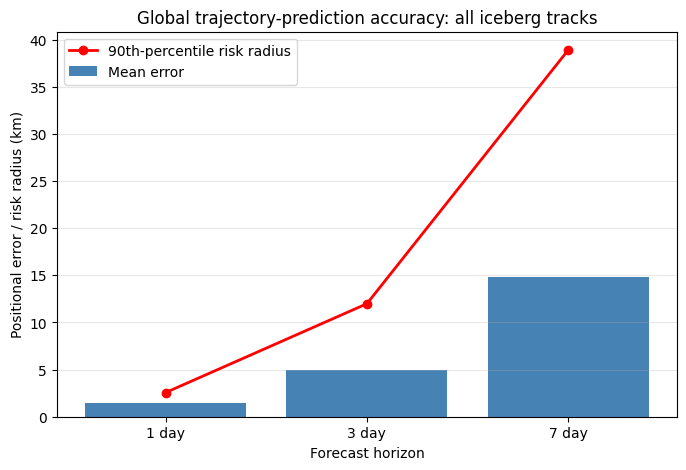

Newest dataset observation: 2026-04-30
Recently active icebergs plotted: 46


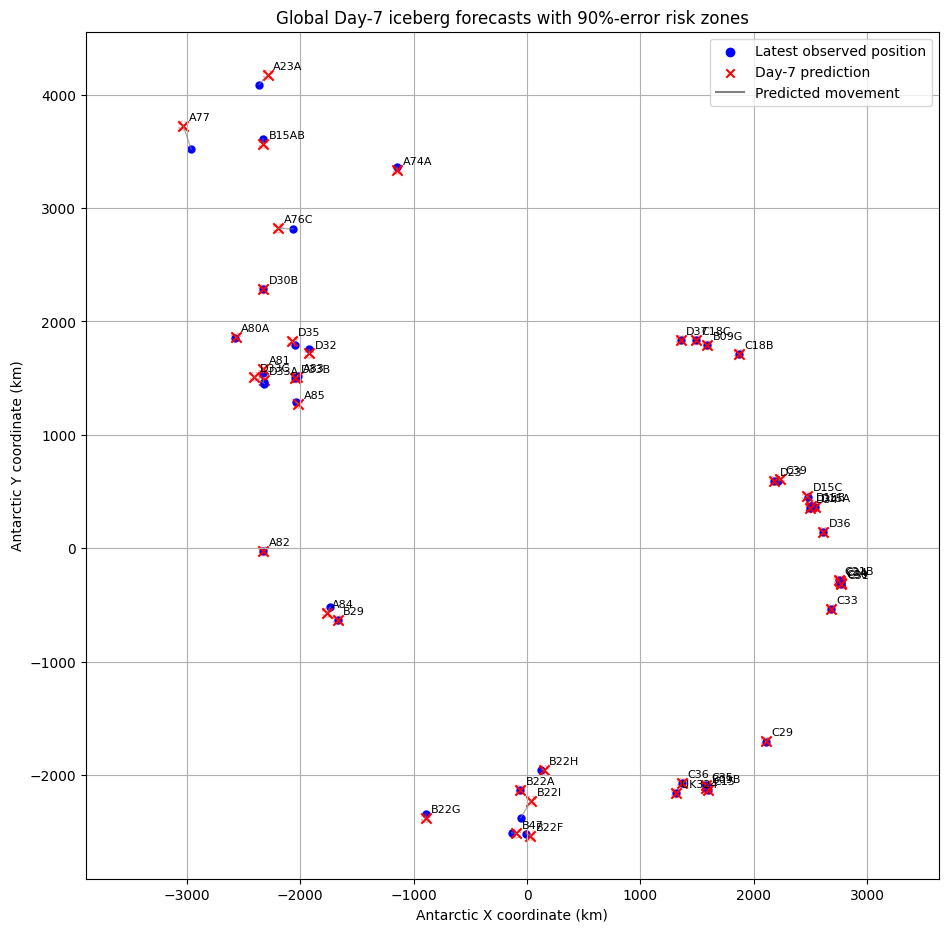

In [60]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from pyproj import Transformer
import pandas as pd

# ------------------------------------------------------------
# 1. Global evaluation-error chart
# ------------------------------------------------------------
metrics_plot = global_metrics.sort_values(
    "forecast_horizon_days"
).copy()

display(
    metrics_plot[[
        "Forecast horizon",
        "Test examples",
        "Mean error (km)",
        "Median error (km)",
        "90th percentile (km)"
    ]].round(3)
)

plt.figure(figsize=(8, 5))

plt.bar(
    metrics_plot["Forecast horizon"],
    metrics_plot["Mean error (km)"],
    color="steelblue",
    label="Mean error"
)

plt.plot(
    metrics_plot["Forecast horizon"],
    metrics_plot["90th percentile (km)"],
    color="red",
    marker="o",
    linewidth=2,
    label="90th-percentile risk radius"
)

plt.title("Global trajectory-prediction accuracy: all iceberg tracks")
plt.xlabel("Forecast horizon")
plt.ylabel("Positional error / risk radius (km)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 2. Plot only recently active iceberg forecasts
# ------------------------------------------------------------

# "Recent" means observed within one year of the newest dataset record.
latest_positions = (
    tracks
    .sort_values(["iceberg_id", "date"])
    .groupby("iceberg_id")
    .tail(1)
    .copy()
)

newest_dataset_date = latest_positions["date"].max()
recent_cutoff = newest_dataset_date - pd.Timedelta(days=365)

active_positions = latest_positions[
    latest_positions["date"] >= recent_cutoff
].copy()

# Select only Day-7 forecast points for those active icebergs.
active_day7 = global_forecast[
    global_forecast["forecast_horizon_days"] == 7
].merge(
    active_positions[[
        "iceberg_id",
        "date",
        "x_m",
        "y_m"
    ]],
    on="iceberg_id",
    how="inner"
)

# Convert forecast latitude/longitude back to Antarctica map metres.
to_antarctic = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3031",
    always_xy=True
)

active_day7["pred_x_m"], active_day7["pred_y_m"] = (
    to_antarctic.transform(
        active_day7["predicted_longitude"].to_numpy(),
        active_day7["predicted_latitude"].to_numpy()
    )
)

print("Newest dataset observation:", newest_dataset_date.date())
print("Recently active icebergs plotted:", len(active_day7))

# ------------------------------------------------------------
# 3. Global Day-7 risk-zone map
# ------------------------------------------------------------
plt.figure(figsize=(11, 11))

for _, row in active_day7.iterrows():
    # Blue = latest observed position
    plt.scatter(
        row["x_m"] / 1000,
        row["y_m"] / 1000,
        color="blue",
        s=25
    )

    # Red X = predicted Day-7 point
    plt.scatter(
        row["pred_x_m"] / 1000,
        row["pred_y_m"] / 1000,
        color="red",
        marker="x",
        s=55
    )

    # Line = predicted movement direction
    plt.plot(
        [row["x_m"] / 1000, row["pred_x_m"] / 1000],
        [row["y_m"] / 1000, row["pred_y_m"] / 1000],
        color="gray",
        linewidth=0.8,
        alpha=0.7
    )

    # Dashed circle = global Day-7 90th-percentile risk radius
    plt.gca().add_patch(
        Circle(
            (row["pred_x_m"] / 1000, row["pred_y_m"] / 1000),
            row["risk_radius_km_p90"],
            fill=False,
            linestyle="--",
            color="red",
            alpha=0.35
        )
    )

    plt.annotate(
        row["iceberg_id"],
        (row["pred_x_m"] / 1000, row["pred_y_m"] / 1000),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

# Legend markers
plt.scatter([], [], color="blue", label="Latest observed position")
plt.scatter([], [], color="red", marker="x", label="Day-7 prediction")
plt.plot([], [], color="gray", label="Predicted movement")

plt.title(
    "Global Day-7 iceberg forecasts with 90%-error risk zones"
)
plt.xlabel("Antarctic X coordinate (km)")
plt.ylabel("Antarctic Y coordinate (km)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

In [63]:
from google.colab import files

files.download("/content/global_iceberg_trajectory_forecasts.csv")
files.download("/content/global_trajectory_validation_metrics.csv")
files.download("/content/a23a_all_model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
!ls /content

 a23a_2020_prediction_results.csv
 a23a_7_day_forecast.csv
 a23a_ade_fde_per_forecast.csv
 a23a_ade_fde_summary.csv
 a23a_all_model_comparison.csv
 a23a_final_forecast.csv
 a23a_final_summary.json
 a23a_final_validation_metrics.csv
 a23a_mvp_forecast.csv
 a23a_mvp_summary.json
 a23a_mvp_validation_metrics.csv
 a23a_selected_model_forecast.csv
 a23a_selected_model_metrics.csv
 a23a_wind_current_trajectory_models.joblib
'cmems_mod_glo_phy_my_0.083deg_P1D-m_1788122023641 (1).nc'
 cmems_mod_glo_phy_my_0.083deg_P1D-m_1788122023641.nc
 consolidated_database_v8.0.zip
 era5_a23a_wind_2018_2020.nc
 era5_wind_sample_2020_01.nc
 global_iceberg_trajectory_forecasts.csv
 global_trajectory_validation_metrics.csv
 iceberg_data
 iceberg_xgboost_model.joblib
 sample_data
 trajectory_model_metrics.csv


In [67]:
files.download("/content/a23a_ade_fde_per_forecast.csv")
files.download("/content/a23a_ade_fde_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>